In [5]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rxr
import pickle
from astropy.time import Time
from pathlib import Path

### Load the file output by the process_icesat2.ipynb

In [6]:
atl06sr_gdf = pickle.load(open('../data/icesat2/sierras_gdf_2018_2021_sa_processed.pkl', 'rb'))

In [7]:
sierras = gpd.read_file('../data/misc/sierras_polygon_gmba.geojson')

In [4]:
#sierras.to_crs('epsg:9822').area / 1e6

0    62494.20166
dtype: float64

In [8]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2018, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 31GB
Dimensions:      (time: 1461, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 12kB 2017-10-01 2017-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 10GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 10GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 10GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [93]:
pwd

'/Users/hannah/Documents/Grad_Documents/Research/analog_snowmapping/notebooks'

In [96]:
stations = pickle.load(open('../../correlated-domains/data/snv_dataframes/snv_temp_precip_cluster_gdf_snvs_quantiles.pkl','rb'))

/var/folders/s4/pymynk_14w75x2ghv0xjkqlm0000gn/T/ipykernel_96577/2482075034.py:1: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  stations = pickle.load(open('../../correlated-domains/data/snv_dataframes/snv_temp_precip_cluster_gdf_snvs_quantiles.pkl','rb'))


In [97]:
stations

station_n  reanalysis_n  elevation_m  station_swe  \
station     year                                                      
301_CA_SNTL 1990  -0.492262     -0.194751  1886.712036     0.193040   
            1991  -0.806681      0.193222  1886.712036     0.142240   
            1992  -1.639892     -1.097426  1886.712036     0.007620   
            1993   0.938344     -0.578276  1886.712036     0.424180   
            1994  -0.335053     -0.422643  1886.712036     0.218440   
...                     ...           ...          ...          ...   
BLD         2017   0.619445      1.160298  2194.560000     1.033272   
            2018  -0.806206     -1.171988  2194.560000     0.371856   
            2019   0.501188      1.293572  2194.560000     0.978408   
            2020  -0.615681     -0.258835  2194.560000     0.460248   
            2021  -0.418586     -0.760679  2194.560000     0.551688   

                  station_swe_mean  reanalysis_swe  deg_days_0C  \
station     year                                                  
301_CA_SNTL 1990          0.272574          0.1718         57.0   
            1991          0.272574          0.2416         47.0   
            1992          0.272574          0.0094         64.0   
            1993          0.272574          0.1028         42.0   
            1994          0.272574          0.1308         48.0   
...                            ...             ...          ...   
BLD         2017          0.745887          1.1946         54.0   
            2018          0.745887          0.1796         82.0   
            2019          0.745887          1.2526         59.0   
            2020          0.745887          0.5770         68.0   
            2021          0.745887          0.3586         55.0   

                  cold_deg_days  cumulative_precip_m  precip_mean  ...  \
station     year                                                   ...   
301_CA_SNTL 1990            0.0             0.223842     0.332045  ...   
            1991            0.0             0.237158     0.332045  ...   
            1992            0.0             0.197154     0.332045  ...   
            1993            0.0             0.449491     0.332045  ...   
            1994            0.0             0.223718     0.332045  ...   
...                         ...                  ...          ...  ...   
BLD         2017            0.0             1.722192     0.846466  ...   
            2018            0.0             0.807857     0.846466  ...   
            2019            0.0             1.363057     0.846466  ...   
            2020            0.0             0.671916     0.846466  ...   
            2021            0.0             0.578816     0.846466  ...   

                  log_station_n  log_reanalysis_n   latitude   longitude  \
station     year                                                           
301_CA_SNTL 1990            NaN               NaN  41.235828 -120.791924   
            1991            NaN               NaN  41.235828 -120.791924   
            1992            NaN               NaN  41.235828 -120.791924   
            1993            NaN               NaN  41.235828 -120.791924   
            1994            NaN               NaN  41.235828 -120.791924   
...                         ...               ...        ...         ...   
BLD         2017       0.712421               NaN  38.451256 -120.034882   
            2018      -0.648226               NaN  38.451256 -120.034882   
            2019       0.639782               NaN  38.451256 -120.034882   
            2020      -0.364297               NaN  38.451256 -120.034882   
            2021      -0.123027               NaN  38.451256 -120.034882   

                                     geometry  cluster  \
station     year                                         
301_CA_SNTL 1990  POINT (-120.79192 41.23583)      3.0   
            1991  POINT (-120.79192 41.23583)      3.0   
            1992  POINT (-120.79192 41

In [13]:
atl06sr_gdf.columns

Index(['spot', 'dh_fit_dx', 'h_sigma', 'w_surface_window_final', 'segment_id',
       'y_atc', 'x_atc', 'pflags', 'region', 'rms_misfit', 'h_mean',
       'n_fit_photons', 'gt', 'cycle', 'rgt', 'geometry', 'segment_snowcover',
       'segment_landcover', 'beam_azimuth', 'segment_watermask', 'urban_flag',
       'slope', '3dep', 'aspect', 'time_acq', 'doy', 'decyear', 'dowy',
       'acqdate', 'reanalysis_fsca', 'reanalysis_sd'],
      dtype='object')

In [14]:
# atl06sr_gdf['snow_depth'] = atl06sr_gdf['h_mean'] - atl06sr_gdf['3dep']

In [15]:
# atl06sr_gdf['reanalysis_offset'] = atl06sr_gdf['snow_depth'] - atl06sr_gdf['reanalysis_sd']

In [16]:
# len(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']==0)])

880205

In [17]:
# atl06sr_gdf['snow_depth_plus'] = atl06sr_gdf['snow_depth'] + np.abs(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']==0), 'snow_depth']))

In [18]:
# atl06sr_gdf['reanalysis_offset_plus'] = atl06sr_gdf['snow_depth_plus'] - atl06sr_gdf['reanalysis_sd']

### Compare snow-off ICESat-2 to sampled 10m 3DEP:

In [19]:
atl06sr_gdf.columns

Index(['spot', 'dh_fit_dx', 'h_sigma', 'w_surface_window_final', 'segment_id',
       'y_atc', 'x_atc', 'pflags', 'region', 'rms_misfit', 'h_mean',
       'n_fit_photons', 'gt', 'cycle', 'rgt', 'geometry', 'segment_snowcover',
       'segment_landcover', 'beam_azimuth', 'segment_watermask', 'urban_flag',
       'slope', '3dep', 'aspect', 'time_acq', 'doy', 'decyear', 'dowy',
       'acqdate', 'reanalysis_fsca', 'reanalysis_sd', 'snow_depth',
       'reanalysis_offset', 'snow_depth_plus', 'reanalysis_offset_plus'],
      dtype='object')

In [ ]:
# atl06sr_gdf['reanalysis_offset'] = atl06sr_gdf['snow_depth'] - atl06sr_gdf['reanalysis_sd']

In [20]:
# np.sqrt(len(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_fsca']==0)]))

np.float64(938.1924109690933)

Text(0.5, 1.0, 'snow-off median difference from 3dep: -0.05')

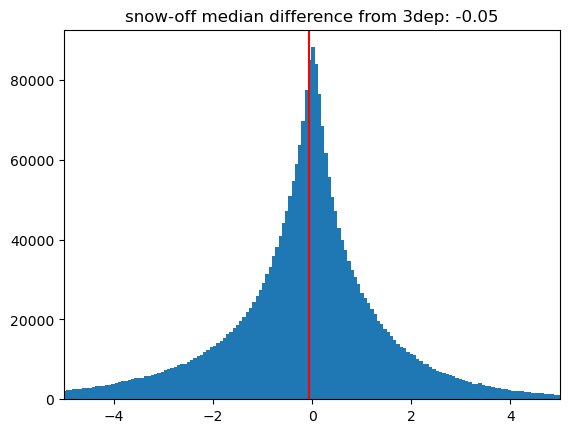

In [9]:
fig, ax = plt.subplots()

ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']==0), 'icesat2_3dep_dif'], bins=int(np.sqrt(len(atl06sr_gdf['icesat2_3dep_dif']))) )
ax.set_xlim(-5,5)
ax.axvline(x=np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']==0), 'icesat2_3dep_dif']), c='red')
ax.set_title(f'snow-off median difference from 3dep: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']==0), 'icesat2_3dep_dif']):.2f}')

Text(0.5, 1.0, 'snow-off median difference from 3dep: 0.00')

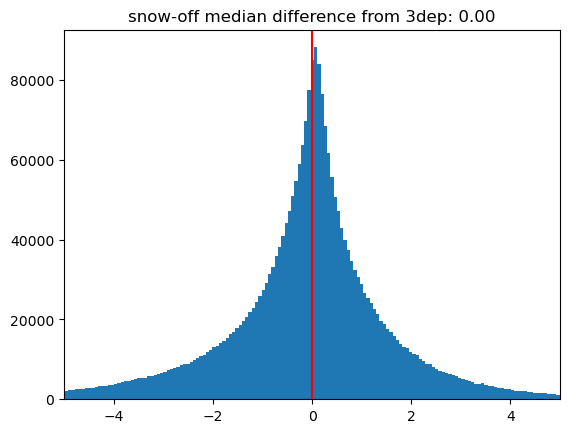

In [10]:
fig, ax = plt.subplots()

ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']==0), 'dif_plus'], bins=int(np.sqrt(len(atl06sr_gdf['dif_plus']))) )
ax.set_xlim(-5,5)
ax.axvline(x=np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']==0), 'dif_plus']), c='red')
ax.set_title(f'snow-off median difference from 3dep: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']==0), 'dif_plus']):.2f}')

Text(0.5, 1.0, 'snow-off median difference from 3dep: 0.55')

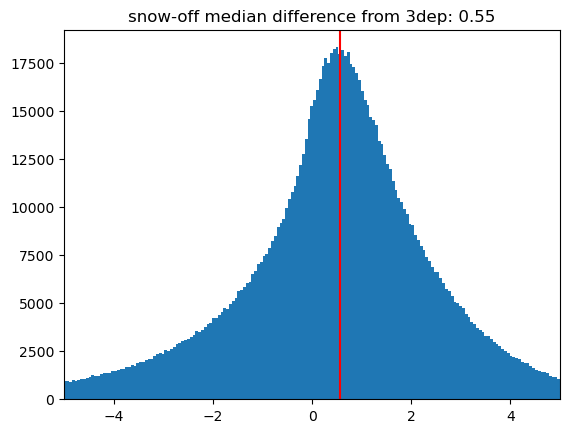

In [11]:
fig, ax = plt.subplots()

ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5), 'icesat2_3dep_dif'], bins=int(np.sqrt(len(atl06sr_gdf['icesat2_3dep_dif']))) )
ax.set_xlim(-5,5)
ax.axvline(x=np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5), 'icesat2_3dep_dif']), c='red')
ax.set_title(f'snow-off median difference from 3dep: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5), 'icesat2_3dep_dif']):.2f}')

### Compare to Tuolumne data from paper to check data quantity:

In [12]:
tuol = gpd.read_file('../data/misc/UpperTuolRiverBasinOutline.geojson')

<Axes: >

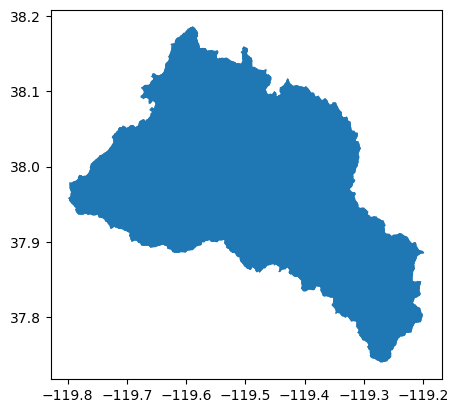

In [ ]:
tuol.plot()

In [13]:
tuol_atl06sr = atl06sr_gdf.clip(tuol.to_crs(atl06sr_gdf.crs))

<Axes: >

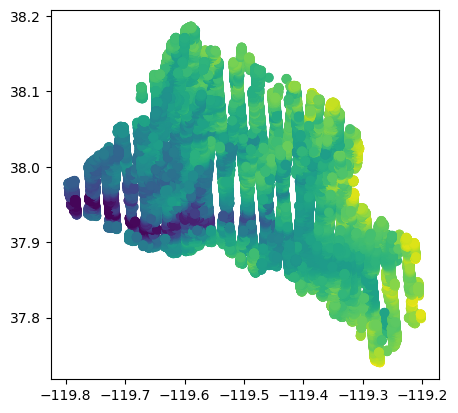

In [14]:
tuol_atl06sr.plot(column='h_mean')

In [15]:
atl06sr_orig = pickle.load(open('../data/icesat2/tuolumne_all_sr-atl06-09282022_processed_bicubic_snowonaso_shapely.pkl', 'rb'))

In [19]:
atl06sr_orig.crs

<Projected CRS: EPSG:32611>
Name: WGS 84 / UTM zone 11N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 120°W and 114°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Alberta; British Columbia (BC); Northwest Territories (NWT); Nunavut. Mexico. United States (USA).
- bounds: (-120.0, 0.0, -114.0, 84.0)
Coordinate Operation:
- name: UTM zone 11N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [20]:
atl06sr_orig.columns

Index(['distance', 'h_sigma', 'rgt', 'delta_time', 'pflags', 'dh_fit_dy',
       'segment_id', 'w_surface_window_final', 'dh_fit_dx', 'h_mean', 'spot',
       'gt', 'cycle', 'rms_misfit', 'n_fit_photons', 'geometry', 'doy',
       'decyear', 'dowy', 'snow_presence', 'lidar_z', 'difference',
       'bicubic_lidar_z', 'sampling_dif', 'difference_bicubic', 'site',
       'acqdate', 'n', 'diff_plus', 'diff_plus_bicubic', 'zscore',
       'ASO_snowon', 'ASO_snowon_date', 'ASO_snowon_bic', 'median_slope20d'],
      dtype='object')

In [16]:
atl06sr_orig = atl06sr_orig.to_crs(tuol_atl06sr.crs)

<Axes: >

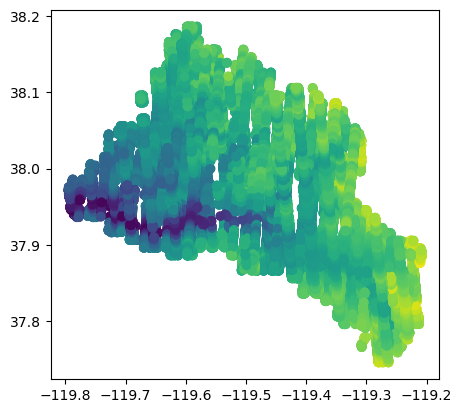

In [17]:
atl06sr_orig.plot(column='h_mean')

In [21]:
atl06sr_orig_2018_2021 = atl06sr_orig['2018-09-30 08:00:00.000000000':'2021-10-01 08:00:00.000000000']

In [22]:
len(atl06sr_orig_2018_2021['acqdate'].unique())

48

In [19]:
len(tuol_atl06sr['acqdate'].unique())

53

In [27]:
atl06sr_orig_2018_2021.shape[0] - tuol_atl06sr.shape[0]

-24196

In [25]:
tuol_atl06sr.shape

(153164, 45)

<Axes: >

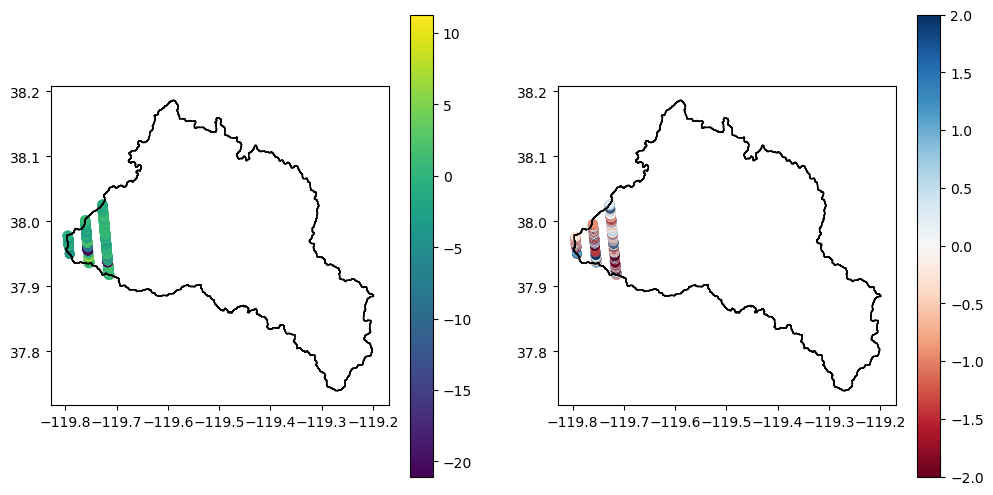

In [23]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

tuol_atl06sr.loc['2021-04-11'].to_crs('epsg:4326').plot(ax=ax[0], column='dif_plus', legend=True)
atl06sr_orig.loc['2021-04-11'].to_crs('epsg:4326').plot(ax=ax[1], column='difference', legend=True, vmin=-2, vmax=2, cmap='RdBu')

tuol.to_crs('epsg:4326').plot(ax=ax[0],facecolor='none')
tuol.to_crs('epsg:4326').plot(ax=ax[1],facecolor='none')


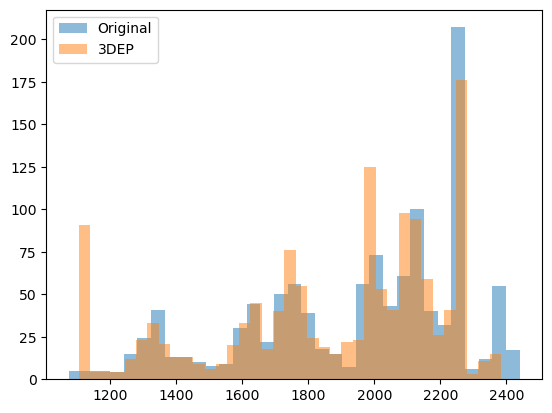

In [28]:
fig, ax = plt.subplots()

ax.hist(atl06sr_orig.loc['2021-04-11', 'h_mean'], bins=int(np.sqrt(len(atl06sr_orig.loc['2021-04-11', 'difference']))), alpha=0.5, label='Original')
ax.hist(tuol_atl06sr.loc['2021-04-11', 'h_mean'], bins=int(np.sqrt(len(tuol_atl06sr.loc['2021-04-11', 'icesat2_3dep_dif']))), alpha=0.5, label='3DEP')
plt.legend()
#ax.set_xlim(-5, 5)

(-5.0, 5.0)

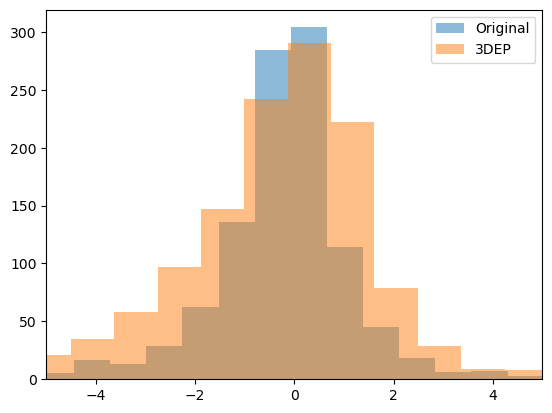

In [31]:
fig, ax = plt.subplots()

ax.hist(atl06sr_orig_2018_2021.loc['2021-04-11', 'difference'], bins=int(np.sqrt(len(atl06sr_orig_2018_2021.loc['2021-04-11', 'difference']))), alpha=0.5, label='Original')
ax.hist(tuol_atl06sr.loc['2021-04-11', 'icesat2_3dep_dif'], bins=int(np.sqrt(len(tuol_atl06sr.loc['2021-04-11', 'icesat2_3dep_dif']))), alpha=0.5, label='3DEP')
plt.legend()
ax.set_xlim(-5, 5)


Text(0.5, 0, 'Slope (degrees)')

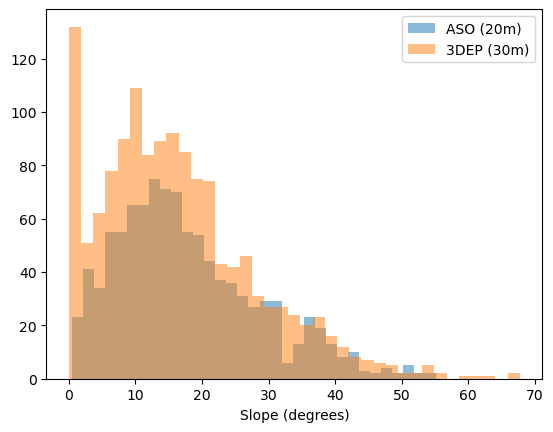

In [32]:
fig, ax = plt.subplots()

ax.hist(atl06sr_orig_2018_2021.loc['2021-04-11', 'median_slope20d'], bins=int(np.sqrt(len(atl06sr_orig_2018_2021.loc['2021-04-11', 'median_slope20d']))), alpha=0.5, label='ASO (20m)')
ax.hist(tuol_atl06sr.loc['2021-04-11', 'slope'], bins=int(np.sqrt(len(tuol_atl06sr.loc['2021-04-11', 'slope']))), alpha=0.5, label='3DEP (30m)')
plt.legend()
plt.xlabel('Slope (degrees)')
#ax.set_xlim(-5, 5)

### Remake the boxplot figures from the masters work:

In [33]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from astropy.time import Time
import datetime
#from rasterstats import zonal_stats
import pickle

In [34]:
import matplotlib.dates as mdates
import matplotlib.cbook as cbook

In [35]:
mpl_epoch = '1970-01-01'

In [36]:
from datetime import datetime

In [37]:
atl06sr_gdf['acqdate']

time_ns
2018-10-14 11:40:32.487777792    2018-10-14
2018-10-14 11:40:32.490599168    2018-10-14
2018-10-14 11:40:32.493418752    2018-10-14
2018-10-14 11:40:32.496237568    2018-10-14
2018-10-14 11:40:32.499053056    2018-10-14
                                    ...    
2021-09-30 07:56:05.208622336    2021-09-30
2021-09-30 07:56:05.211433728    2021-09-30
2021-09-30 07:56:05.214239488    2021-09-30
2021-09-30 07:56:05.217039872    2021-09-30
2021-09-30 07:56:05.219838720    2021-09-30
Name: acqdate, Length: 4672860, dtype: object

### Load snotel data for comparison  
Using Eric Gagliano's awesome github access notebooks and csvs!

In [38]:
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

In [39]:
sierra_stations = all_stations_gdf.clip(sierras.geometry)

In [ ]:
sierra_stations.astype(dict(beginDate=str, endDate=str)).explore(column='network',cmap='bwr')

In [40]:
sierra_station_codes = list(sierra_stations.index.values)
sierra_station_codes

['PSC',
 'QUA',
 'BCH',
 'CSV',
 'WTM',
 'TUN',
 'FRW',
 'CWD',
 'CHP',
 'GNF',
 'CBT',
 'UTY',
 'BIM',
 'MTM',
 'CRL',
 'STL',
 'WWC',
 'BCB',
 'BSH',
 'BGP',
 'SWM',
 'TMR',
 'SLK',
 'UBC',
 'HNT',
 'KSP',
 'VLC',
 'RCK',
 'GRV',
 'GRM',
 'PSR',
 'CHM',
 'STR',
 'GIN',
 'TNY',
 'WHW',
 'KIB',
 'PDS',
 'HRS',
 'GNL',
 'MHP',
 'DPO',
 'AGP',
 'GEM',
 'TUM',
 'DAN',
 'TES',
 '846_CA_SNTL',
 'VRG',
 'SLI',
 'REL',
 '574_CA_SNTL',
 'LVT',
 '575_CA_SNTL',
 'LVM',
 '771_CA_SNTL',
 'SPS',
 'DDM',
 'BLS',
 '1052_CA_SNTL',
 'SDW',
 'BLD',
 'HHM',
 'PSN',
 'SLM',
 '697_CA_SNTL',
 '462_CA_SNTL',
 'EBB',
 '356_CA_SNTL',
 'BLK',
 'MDL',
 'SPT',
 '778_CA_SNTL',
 '633_CA_SNTL',
 'MNT',
 'SIL',
 'FDC',
 '1049_CA_SNTL',
 'CXS',
 '1067_CA_SNTL',
 'CAP',
 'BSK',
 '1051_CA_SNTL',
 'SCN',
 'FRN',
 'ALP',
 'HOR',
 '1050_CA_SNTL',
 '463_CA_SNTL',
 'EP5',
 '508_CA_SNTL',
 'HGM',
 'RBP',
 'RBB',
 'LOS',
 '518_CA_SNTL',
 'HVN',
 'VVL',
 '724_CA_SNTL',
 'RP2',
 '848_CA_SNTL',
 'WC3',
 '615_NV_SNTL',
 'TCC',
 '8

In [41]:
#station_list = ['356_CA_SNTL','BLK']

station_dict = {}

for station in sierra_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

sierra_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()

In [44]:
sierra_stations_sd_df

,PSC,QUA,BCH,CSV,WTM,TUN,FRW,CWD,CHP,GNF,...,FOR,BKL,GRZ,HMB,RTL,KTL,539_CA_SNTL,340_NV_SNTL,BMW,INN
datetime,,,,,,,,,,,,,,,,,,,,,
1954-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1954-12-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1954-12-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1954-12-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1954-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-16,0.1016,0.3302,0.1778,0.0,0.1016,0.1016,0.1270,0.1524,NaN,0.1270,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1524,NaN,0.0254
2025-10-17,0.0254,0.2032,0.0762,0.0,0.0000,0.0254,0.0762,0.1016,NaN,0.0254,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1270,NaN,0.0000
2025-10-18,0.0000,0.1016,0.0254,0.0,0.0000,-0.0254,0.0254,0.0508,NaN,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1016,NaN,0.0000


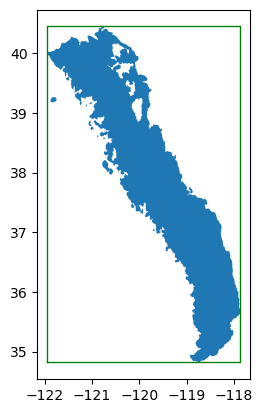

In [42]:
region = [  {"lon": -121.948903, "lat": 34.818611},
            {"lon": -117.862654, "lat": 34.818611},
            {"lon": -117.862654, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 34.818611}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax = plt.subplots()
sierras.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

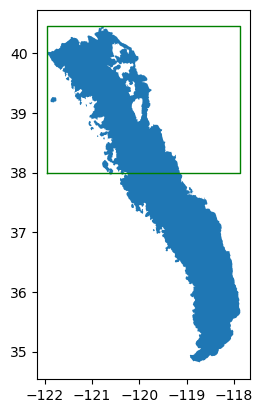

In [46]:
north_sierras = [  {"lon": -121.948903, "lat": 38},
            {"lon": -117.862654, "lat": 38},
            {"lon": -117.862654, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 38}  ]

region_lon = [e["lon"] for e in north_sierras]
region_lat = [e["lat"] for e in north_sierras]

fig, ax = plt.subplots()
sierras.plot(ax=ax)
ax.plot(region_lon, region_lat, linewidth=1, color='g');

In [43]:
# Separate the stations into north and south, with latitude 38 as the cutoff based on Jessica's EOF analysis

from shapely.geometry import box

# Define bounding box coordinates (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = -121.948903, 38, -117.862654, 40.446988
# Create the polygon
bbox_polygon = box(minx, miny, maxx, maxy)
# Make a polygon into a dataframe so it can have a crs
north_sierras_gdf = gpd.GeoDataFrame(geometry=[bbox_polygon], crs='EPSG:4326')


# Clip the stations to the northern section of the Sierras
north_stations = sierra_stations.clip(north_sierras_gdf.geometry)

# Make a list of the codes
north_station_codes = list(north_stations.index.values)

#Download the snow depth data for the stations with those codes
station_dict = {}

for station in north_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

north_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()

# Subset the stations to WY 2021
north_stations_sd_df_2021 = north_stations_sd_df.loc['2020-10-01':'2021-09-30']

In [48]:
north_stations.astype(dict(beginDate=str, endDate=str)).explore(column='network',cmap='bwr')

In [44]:
north_stations_sd_df_2018_2021 = north_stations_sd_df.loc['2018-10-01':'2021-09-30']

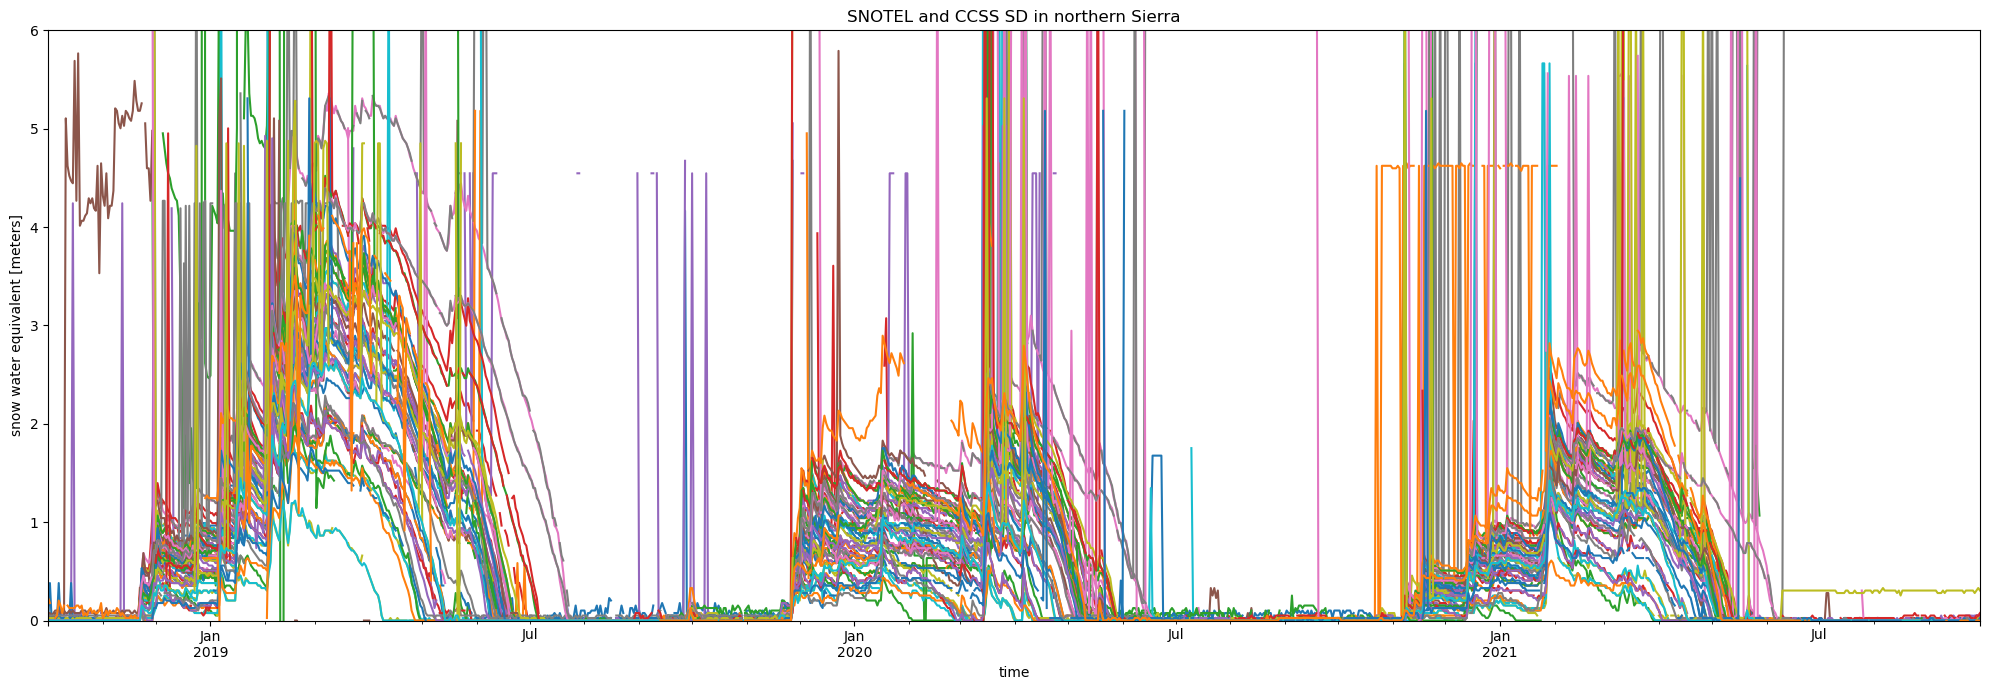

In [45]:
f,ax=plt.subplots(figsize=(20,7))

north_stations_sd_df_2018_2021.plot(ax=ax, legend=False)

#ax.legend()
ax.set_ylim(0,6)

ax.set_xlabel('time')
ax.set_ylabel('snow water equivalent [meters]')
ax.set_title('SNOTEL and CCSS SD in northern Sierra')

f.tight_layout()

In [55]:
atl06sr_gdf

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,doy,decyear,dowy,acqdate,reanalysis_sd,reanalysis_swe,reanalysis_sca,icesat2_3dep_dif,dif_plus,offset_sd
time_ns,,,,,,,,,,,,,,,,,,,,,
2018-10-14 11:40:19.836790528,0.0,1.0,0,1148.935899,6,2.408412e-02,10,78,3.0,390842023936,...,287,2018.784894,14,2018-10-14,NaN,NaN,NaN,0.031996,0.021063,NaN
2018-10-14 11:40:19.839602432,0.0,1.0,0,1148.934065,6,1.579455e-02,10,75,3.0,390842023936,...,287,2018.784894,14,2018-10-14,NaN,NaN,NaN,0.041644,0.030710,NaN
2018-10-14 11:40:19.842414848,0.0,1.0,0,1148.935648,6,2.080928e-02,10,69,3.0,390842023936,...,287,2018.784894,14,2018-10-14,NaN,NaN,NaN,0.031393,0.020460,NaN
2018-10-14 11:40:19.845227008,0.0,1.0,0,1148.938208,6,1.530927e-02,10,74,3.0,390842023936,...,287,2018.784894,14,2018-10-14,NaN,NaN,NaN,0.023706,0.012773,NaN
2018-10-14 11:40:19.848037632,0.0,1.0,0,1148.938449,6,2.478544e-02,10,82,3.0,390842023936,...,287,2018.784894,14,2018-10-14,NaN,NaN,NaN,0.018216,0.007283,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-12 07:31:19.182023680,1.0,0.0,0,-37.478182,6,4.945469e-15,10,31,3.0,64424509440,...,285,2021.778941,12,2021-10-12,NaN,NaN,NaN,0.800246,0.789312,NaN
2021-10-12 07:31:19.184836096,1.0,0.0,0,-37.478513,6,0.000000e+00,10,35,3.0,64424509440,...,285,2021.778941,12,2021-10-12,NaN,NaN,NaN,0.433637,0.422703,NaN
2021-10-12 07:31:19.187649536,1.0,0.0,0,-37.478845,6,4.945469e-15,10,34,3.0,64424509440,...,285,2021.778941,12,2021-10-12,NaN,NaN,NaN,0.063299,0.052365,NaN


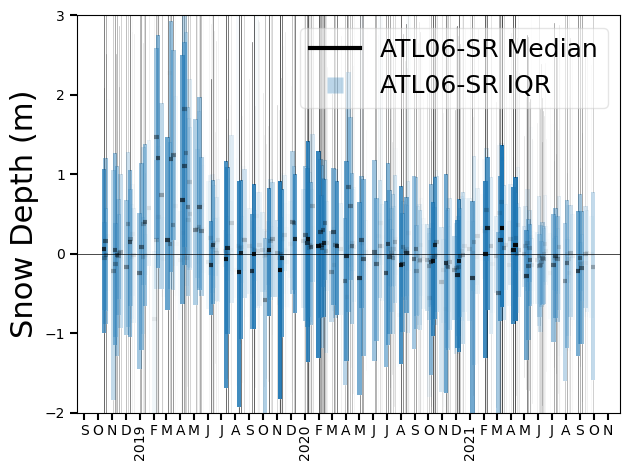

In [46]:
df=atl06sr_gdf
groupby_col='acqdate'
col='icesat2_3dep_dif'

boxplot_color = (31/255,119/255, 180/255, 0.3)

custom = [
          Line2D([], [], linestyle='-', color='k', linewidth=3),
          Line2D([], [], marker='s', markersize=12, markeredgecolor='none', color=boxplot_color, linestyle='None'),
          ]
custom_labels = ['ATL06-SR Median', 'ATL06-SR IQR']

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 3)

fig, ax = plt.subplots()

#north_stations_sd_df_2021.plot(ax=ax, alpha=1,  lw=1, legend=False)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

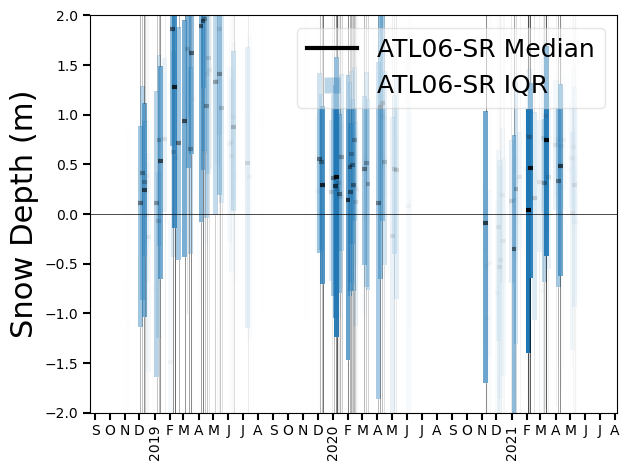

In [47]:
df=atl06sr_gdf[atl06sr_gdf['reanalysis_sca']>0.5]
groupby_col='acqdate'
col='icesat2_3dep_dif'

boxplot_color = (31/255,119/255, 180/255, 0.3)

custom = [
          Line2D([], [], linestyle='-', color='k', linewidth=3),
          Line2D([], [], marker='s', markersize=12, markeredgecolor='none', color=boxplot_color, linestyle='None'),
          ]
custom_labels = ['ATL06-SR Median', 'ATL06-SR IQR']

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

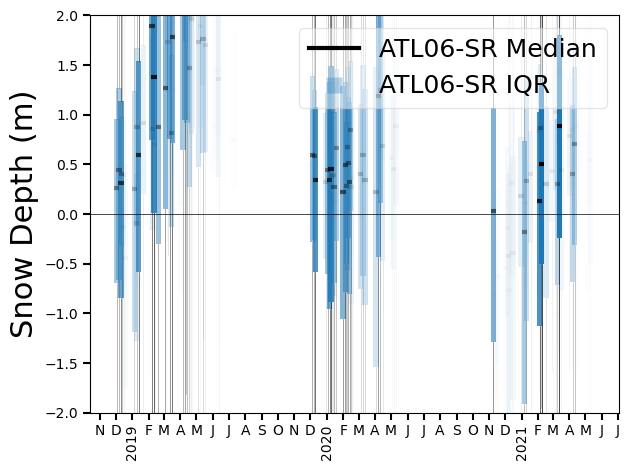

In [48]:
df=atl06sr_gdf[atl06sr_gdf['reanalysis_sca']>0.9]
groupby_col='acqdate'
col='icesat2_3dep_dif'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

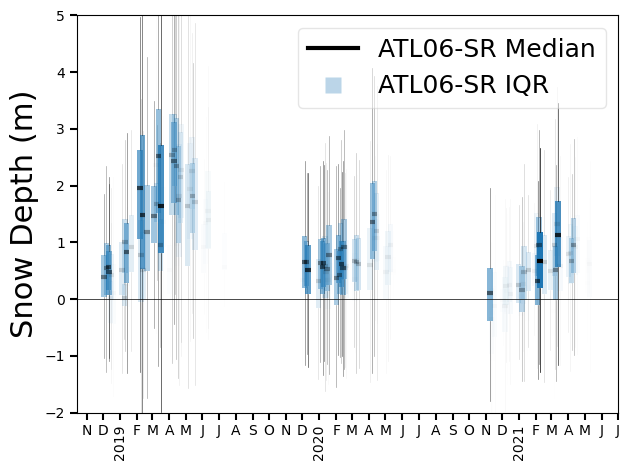

In [50]:
df=atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<10)]
groupby_col='acqdate'
col='icesat2_3dep_dif'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 5)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

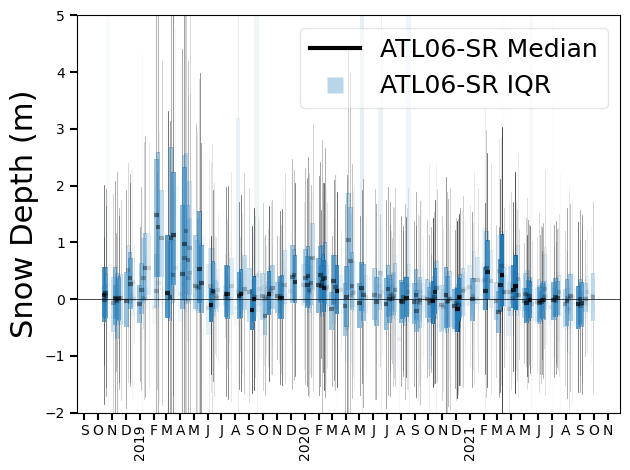

In [51]:
df=atl06sr_gdf.loc[atl06sr_gdf['slope']<10]
groupby_col='acqdate'
col='icesat2_3dep_dif'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 5)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

In [ ]:
# plot snotel plots throughout the sierra to compare
# find a place maybe in the north (more trees, less steep, denser snow, ros) or south (less trees, steeper, colder) that's smaller to look at. subset different basins to explore what's going on
# look at the american, feather, yuba?
# and redownload sliderule data to see if we're missing some points or dates
# see if i can use flagged snow cover and canopy cover in the icesat2 data - can i get this when downloading via sliderule?
# plot data with error bars from a one to one line by elevation, icesat2 versus reanalysis
# desiree used 10 degrees slope to subset

In [72]:
np.nanmin(atl06sr_gdf['h_mean'])

np.float64(1.102746284250586)

In [73]:
np.nanmax(atl06sr_gdf['h_mean'])

np.float64(4225.151067889545)

In [52]:
elev_min = np.arange(1000, 4400, 200)
elev_max = np.arange(1200, 4600, 200)
elev_max

array([1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200,
       3400, 3600, 3800, 4000, 4200, 4400])

In [53]:
slope_min = np.arange(0, 70, 10)
slope_max = np.arange(10, 80, 10)
slope_max

array([10, 20, 30, 40, 50, 60, 70])

In [54]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x_std = []
for x_min, x_max in zip(elev_min, elev_max):
    x_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_std = []
for x_min, x_max in zip(elev_min, elev_max):
    y_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))


/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [95]:
x_std

[np.float64(1.218865929470245),
 np.float64(1.430562895361234),
 np.float64(1.1647472013985156),
 np.float64(0.893863463751636),
 np.float64(1.1084890213265195),
 np.float64(1.2251148917356116),
 np.float64(1.3102884873037897),
 np.float64(2.7906857466847548),
 np.float64(1.4116674436700742),
 np.float64(1.4703850549351005),
 np.float64(1.502162991383669),
 np.float64(1.5669668215151242),
 np.float64(1.3629268513504993),
 np.float64(1.7568276831025358),
 np.float64(2.802170601386212),
 np.float64(nan),
 np.float64(nan)]

Text(0.5, 1.0, 'By Elevation, with all slopes')

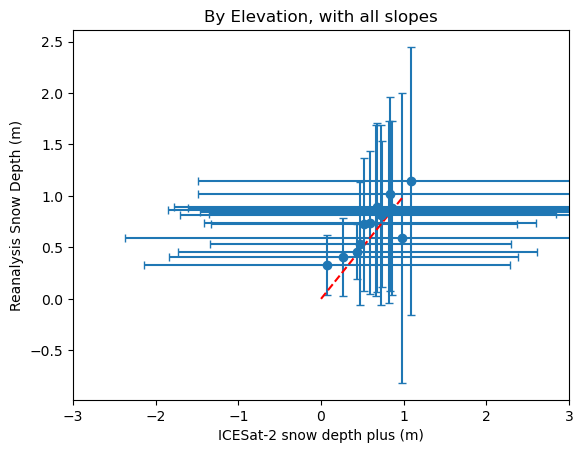

In [55]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x


fig, ax = plt.subplots()

plt.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3)
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')
plt.xlim(-3, 3)
#plt.ylim(-2,2)
plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes')

In [64]:
elev_min

array([1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000,
       3200, 3400, 3600, 3800, 4000, 4200])

In [65]:
elev_max[-1]

np.int64(4400)

Text(0.5, 1.0, 'By Elevation, with all slopes')

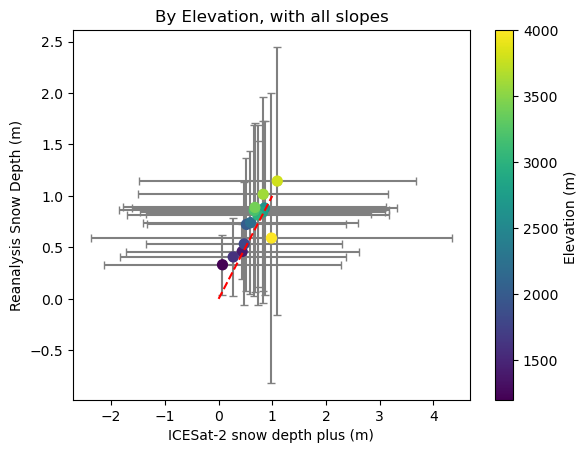

In [56]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

ax.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3, zorder=1, c='grey')
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes')

In [148]:
elev_max

array([1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200,
       3400, 3600, 3800, 4000, 4200, 4400])

(0.0, 1.5)

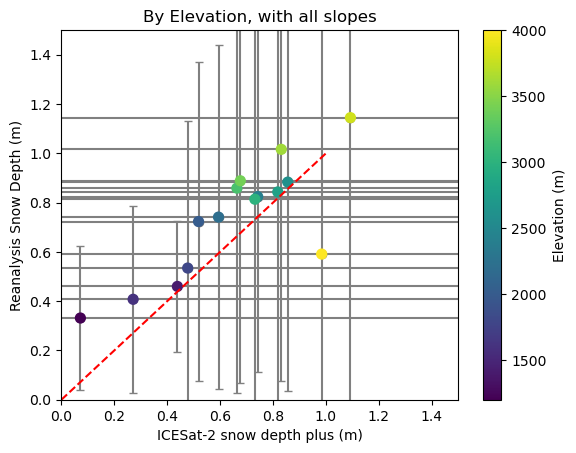

In [57]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

ax.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3, zorder=1, c='grey')
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes')
plt.xlim(0, 1.5)
plt.ylim(0, 1.5)

In [58]:
x_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

x_std = []
for x_min, x_max in zip(slope_min, slope_max):
    x_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_std = []
for x_min, x_max in zip(slope_min, slope_max):
    y_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))


Text(0.5, 1.0, 'By Slope, with all Elevations')

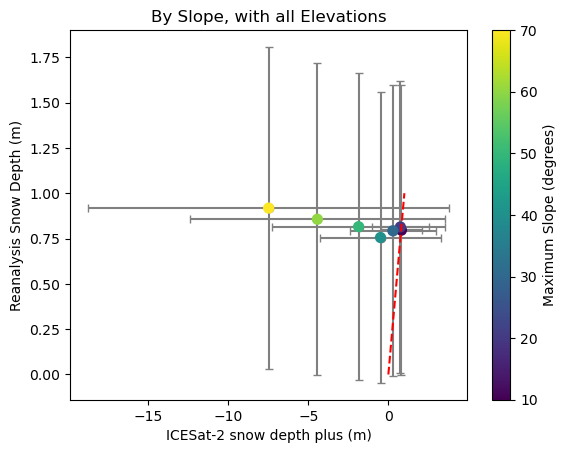

In [59]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

ax.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3, zorder=1, c='grey')
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations')

(-3.0, 3.0)

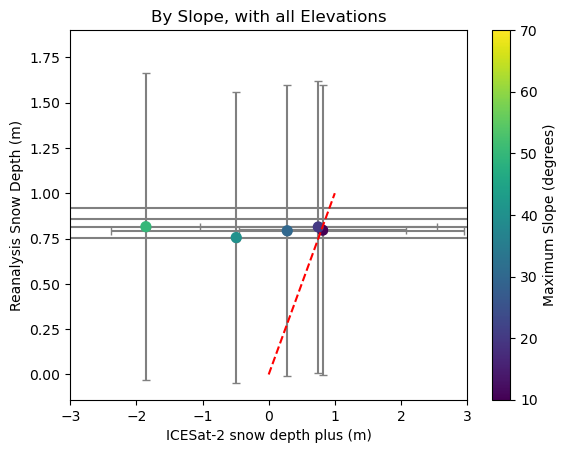

In [60]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

ax.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3, zorder=1, c='grey')
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations')
plt.xlim(-3, 3)

In [61]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<10) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<10) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x_std = []
for x_min, x_max in zip(elev_min, elev_max):
    x_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<10) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_std = []
for x_min, x_max in zip(elev_min, elev_max):
    y_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<10) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))


(0.0, 1.5)

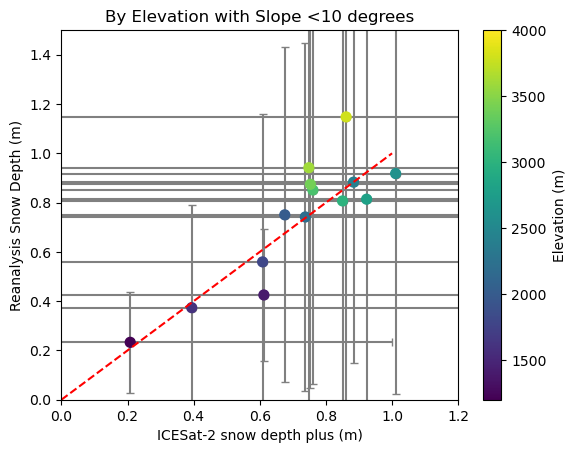

In [64]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

ax.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3, zorder=1, c='grey')
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <10 degrees')
plt.xlim(0, 1.2)
plt.ylim(0, 1.5)

In [65]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x_std = []
for x_min, x_max in zip(elev_min, elev_max):
    x_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_std = []
for x_min, x_max in zip(elev_min, elev_max):
    y_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))


/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


(0.0, 1.5)

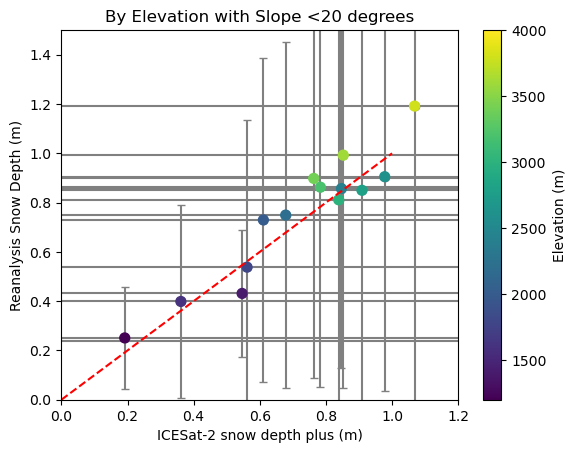

In [66]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

ax.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3, zorder=1, c='grey')
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees')
plt.xlim(0, 1.2)
plt.ylim(0, 1.5)

In [115]:
atl06sr_snowy_20slope = pickle.load(open('../data/icesat2/sierras_gdf_2018_2021_sa_processed_snowy_20slope.pkl', 'rb'))

In [129]:
sample_min = [30,50,70,100, 150, 200, 250, 300, 350, 400]
sample_max = [50,70,100,150, 200, 250, 300, 350, 400, 450]

In [130]:
x_medians = []
for x_min, x_max in zip(sample_min, sample_max):
    x_medians.append(np.nanmedian(atl06sr_snowy_20slope.loc[(atl06sr_snowy_20slope['reanalysis_sca']>0.9) & (atl06sr_snowy_20slope['n']>x_min),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(sample_min, sample_max):
    y_medians.append(np.nanmedian(atl06sr_snowy_20slope.loc[(atl06sr_snowy_20slope['reanalysis_sca']>0.9) & (atl06sr_snowy_20slope['n']>x_min),'reanalysis_sd'].values))

# x_std = []
# for x_min, x_max in zip(sample_min, sample_max):
#     x_std.append(np.nanstd(atl06sr_snowy_20slope.loc[(atl06sr_snowy_20slope['reanalysis_sca']>0.9) & (atl06sr_snowy_20slope['n']>x_min) & (atl06sr_snowy_20slope['n']<x_max),'icesat2_3dep_dif'].values))

# y_std = []
# for x_min, x_max in zip(sample_min, sample_max):
#     y_std.append(np.nanstd(atl06sr_snowy_20slope.loc[(atl06sr_snowy_20slope['reanalysis_sca']>0.9) & (atl06sr_snowy_20slope['n']>x_min) & (atl06sr_snowy_20slope['n']<x_max),'reanalysis_sd'].values))


Text(0.5, 1.0, 'By Sample Size')

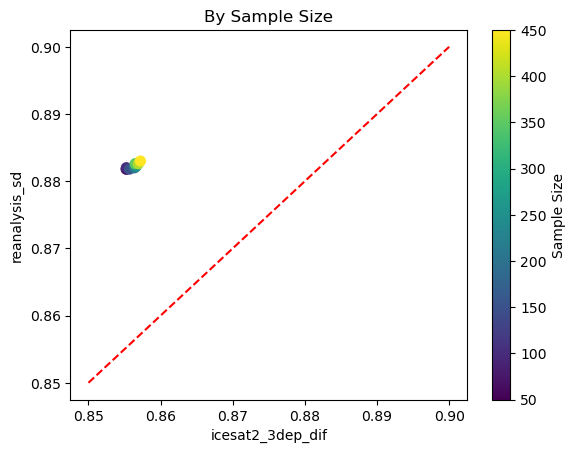

In [133]:
x = np.linspace(0.85, 0.9, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=sample_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Sample Size')

#ax.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3, zorder=1, c='grey')
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('icesat2_3dep_dif')
plt.ylabel('reanalysis_sd')
plt.title('By Sample Size')
#plt.xlim(0, 1.2)
#plt.ylim(0, 1.5)

In [71]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<10) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<10) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x_std = []
for x_min, x_max in zip(elev_min, elev_max):
    x_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<10) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_std = []
for x_min, x_max in zip(elev_min, elev_max):
    y_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<10) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))


(-0.25, 1.5)

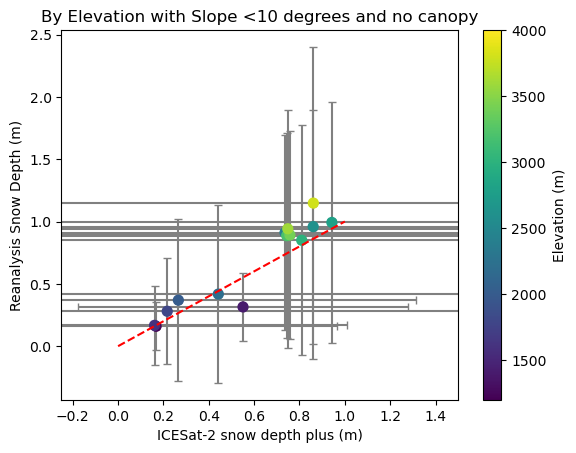

In [73]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

ax.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3, zorder=1, c='grey')
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <10 degrees and no canopy')
plt.xlim(-0.25, 1)
plt.xlim(-0.25, 1.5)

In [74]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x_std = []
for x_min, x_max in zip(elev_min, elev_max):
    x_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_std = []
for x_min, x_max in zip(elev_min, elev_max):
    y_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))


/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


(-0.25, 1.5)

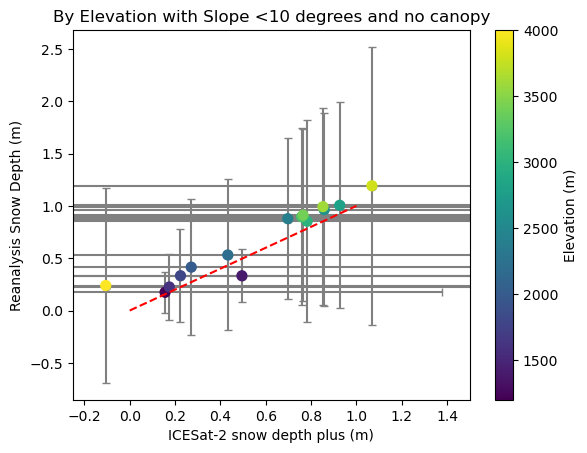

In [75]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

ax.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3, zorder=1, c='grey')
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and no canopy')
plt.xlim(-0.25, 1)
plt.xlim(-0.25, 1.5)

In [78]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x_std = []
for x_min, x_max in zip(elev_min, elev_max):
    x_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_std = []
for x_min, x_max in zip(elev_min, elev_max):
    y_std.append(np.nanstd(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (~atl06sr_gdf['segment_landcover'].isin(canopy_codes)) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))


(-0.25, 1.5)

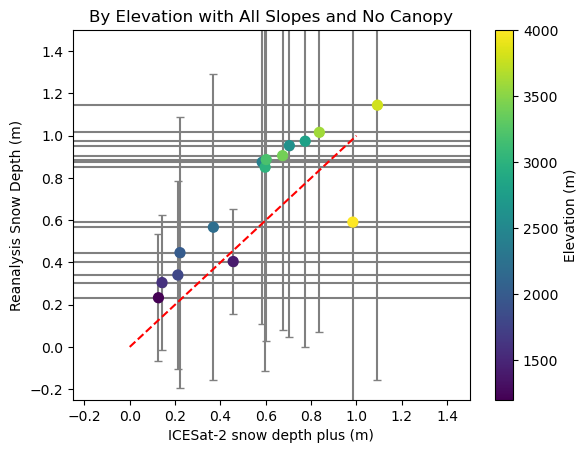

In [80]:
x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

ax.errorbar(x_medians, y_medians, xerr=x_std, yerr=y_std, fmt='o', capsize=3, zorder=1, c='grey')
plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with All Slopes and No Canopy')
plt.xlim(-0.25, 1.5)
plt.ylim(-0.25, 1.5)

In [59]:
#atl06sr_gdf['snow_depth_plus'] = atl06sr_gdf['snow_depth'] + abs(np.nanmedian(atl06sr_gdf.loc[atl06sr_gdf['reanalysis_fsca']==0, 'snow_depth']))

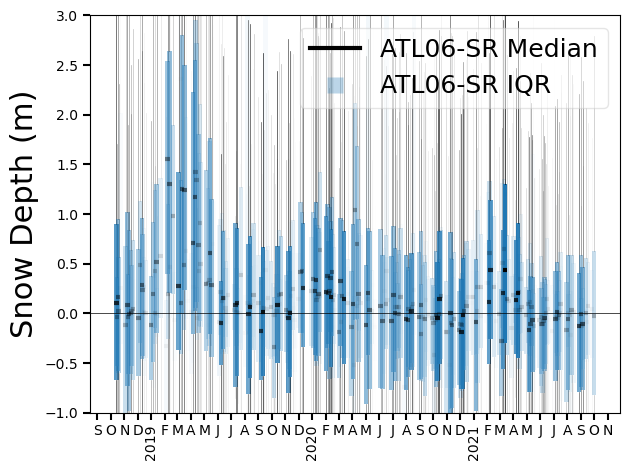

In [83]:
df=atl06sr_gdf[atl06sr_gdf['slope']<20]
groupby_col='acqdate'
col='icesat2_3dep_dif'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-1, 3)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

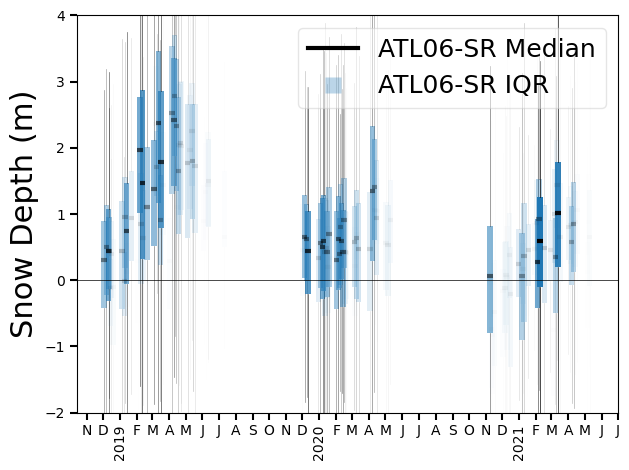

In [85]:
df=atl06sr_gdf.loc[(atl06sr_gdf['slope']<20) & (atl06sr_gdf['reanalysis_sca']>0.9)]
groupby_col='acqdate'
col='icesat2_3dep_dif'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 4)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

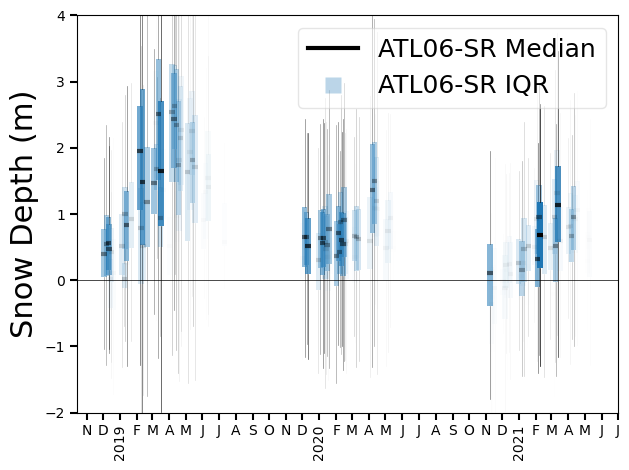

In [86]:
df=atl06sr_gdf.loc[(atl06sr_gdf['slope']<10) & (atl06sr_gdf['reanalysis_sca']>0.9)]
groupby_col='acqdate'
col='icesat2_3dep_dif'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 4)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

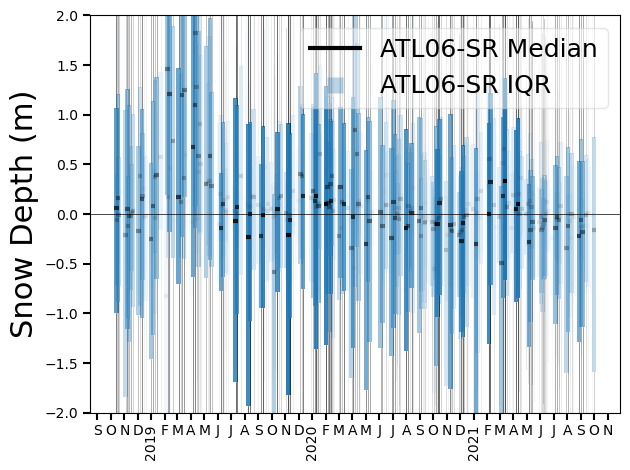

In [87]:
df=atl06sr_gdf#.loc[atl06sr_gdf['3dep']]
groupby_col='acqdate'
col='icesat2_3dep_dif'

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2)

fig, ax = plt.subplots()
bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='upper right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')


plt.tight_layout()

### Vegetation subsetting:

In [69]:
canopy_codes = [111, 113, 112, 114, 115, 116, 121, 123, 122, 124, 125, 126]
#no_canopy_codes = []

In [212]:
atl06sr_gdf.columns

Index(['spot', 'dh_fit_dx', 'h_sigma', 'w_surface_window_final', 'segment_id',
       'y_atc', 'x_atc', 'pflags', 'region', 'rms_misfit', 'h_mean',
       'n_fit_photons', 'gt', 'cycle', 'rgt', 'geometry', 'segment_snowcover',
       'segment_landcover', 'beam_azimuth', 'segment_watermask', 'urban_flag',
       'slope', '3dep', 'aspect', 'time_acq', 'doy', 'decyear', 'dowy',
       'acqdate', 'reanalysis_fsca', 'reanalysis_sd', 'snow_depth',
       'reanalysis_offset', 'snow_depth_plus', 'reanalysis_offset_plus'],
      dtype='object')

In [83]:
atl06sr_gdf[~atl06sr_gdf['segment_landcover'].isin(canopy_codes)].shape

(3676132, 45)

In [217]:
atl06sr_gdf[atl06sr_gdf['segment_landcover'].isin(canopy_codes)].shape

(218420, 35)

In [218]:
atl06sr_gdf.shape

(1470017, 35)

### Zoom in to smaller watersheds 

In [88]:
huc10 = gpd.read_file('../data/misc/WBD_18_HU2_Shape/Shape/WBDHU10.shp')
huc10_2 = gpd.read_file('../data/misc/WBD_16_HU2_Shape2/Shape/WBDHU10.shp')

In [89]:
huc8 = gpd.read_file('../data/misc/WBD_18_HU2_Shape/Shape/WBDHU8.shp')
huc8_2 = gpd.read_file('../data/misc/WBD_16_HU2_Shape2/Shape/WBDHU8.shp')

In [90]:
huc8_clip = huc8.to_crs(sierras.crs).clip(sierras)
huc8_2_clip = huc8_2.to_crs(sierras.crs).clip(sierras)
huc8_sierra = pd.concat([huc8_clip, huc8_2_clip], ignore_index=True)

<Axes: >

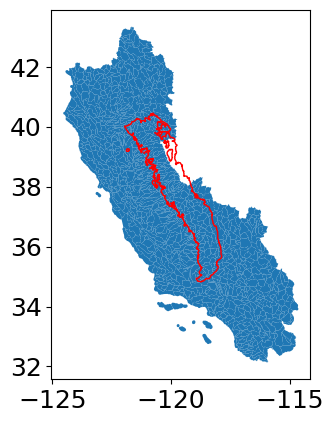

In [118]:
fig, ax = plt.subplots()
huc10.plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

In [115]:
huc10.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

<Axes: >

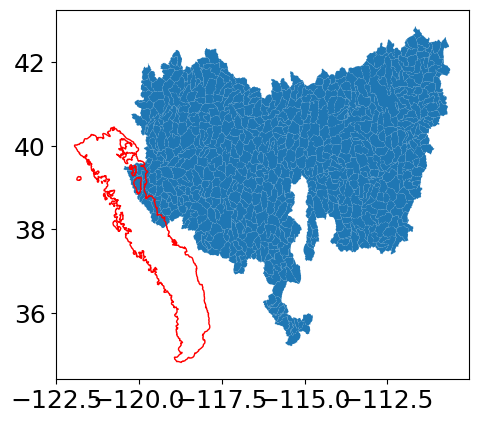

In [122]:
fig, ax = plt.subplots()
huc10_2.plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

In [91]:
huc10_clip = huc10.to_crs(sierras.crs).clip(sierras)
huc10_2_clip = huc10_2.to_crs(sierras.crs).clip(sierras)
huc10_sierra = pd.concat([huc10_clip, huc10_2_clip], ignore_index=True)

<Axes: >

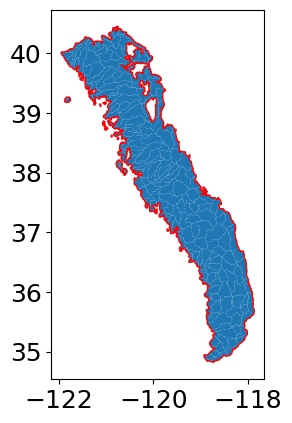

In [133]:
fig, ax = plt.subplots()
huc10_sierra.plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

<Axes: >

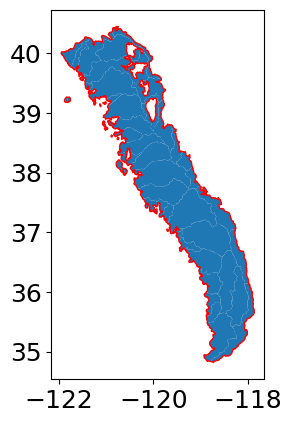

In [165]:
fig, ax = plt.subplots()
huc8_sierra.plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

## North Sierra:  

<Axes: >

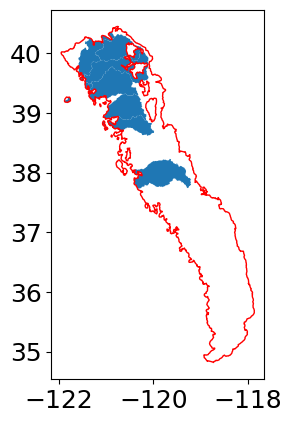

In [ ]:
fig, ax = plt.subplots()
huc8_sierra[(huc8_sierra['name'].str.contains('American|Feather|Tuolumne|Yuba'))].plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

#huc10_sierra[huc10_sierra['name']=='Upper North Fork American River'].plot()

In [92]:
# Separate the stations into north and south, with latitude 38 as the cutoff based on Jessica's EOF analysis

from shapely.geometry import box

# Define bounding box coordinates (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = -121.948903, 38, -117.862654, 40.446988
# Create the polygon
bbox_polygon = box(minx, miny, maxx, maxy)
# Make a polygon into a dataframe so it can have a crs
north_sierras_gdf = gpd.GeoDataFrame(geometry=[bbox_polygon], crs='EPSG:4326')


# Clip the stations to the northern section of the Sierras
north_stations = sierra_stations.clip(north_sierras_gdf.geometry)

# Make a list of the codes
north_station_codes = list(north_stations.index.values)

#Download the snow depth data for the stations with those codes
station_dict = {}

for station in north_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

north_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()

# Subset the stations to WY 2021
north_stations_sd_df_2018_2021 = north_stations_sd_df.loc['2018-10-01':'2021-09-30']

In [93]:
north_stations_sd_df_2018_2021_na = north_stations_sd_df_2018_2021.dropna(axis=1, how='all')

In [86]:
df

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,doy,decyear,dowy,acqdate,reanalysis_sd,reanalysis_swe,reanalysis_sca,icesat2_3dep_dif,dif_plus,offset_sd
time_ns,,,,,,,,,,,,,,,,,,,,,
2021-05-08 14:55:09.217460992,0.0,1.0,0,1998.860126,6,1.503606,10,18,3.0,511101108224,...,128,2021.349648,220,2021-05-08,0.0022,0.0008,0.004,-0.189228,-0.200161,-0.202361
2019-08-11 21:16:21.239139840,0.0,1.0,0,1642.852855,6,4.130471,10,52,3.0,399431958528,...,223,2019.610648,315,2019-08-11,0.0000,0.0000,0.000,-0.314403,-0.325337,-0.325337
2019-08-11 21:16:21.126801664,0.0,1.0,0,1847.624329,6,5.486439,10,86,3.0,399431958528,...,223,2019.610648,315,2019-08-11,0.0000,0.0000,0.000,-0.502869,-0.513803,-0.513803
2019-08-11 21:16:21.123969536,0.0,1.0,0,1848.949258,6,4.291442,10,133,3.0,399431958528,...,223,2019.610648,315,2019-08-11,0.0000,0.0000,0.000,-0.538614,-0.549547,-0.549547
2019-08-11 21:16:21.121174784,0.0,1.0,0,1849.447879,6,4.600743,10,117,3.0,399431958528,...,223,2019.610648,315,2019-08-11,0.0000,0.0000,0.000,0.133176,0.122243,0.122243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-05-18 13:10:21.206784768,0.0,1.0,0,1467.517736,2,2.711950,10,36,3.0,201863462912,...,138,2019.376846,230,2019-05-18,0.0000,0.0000,0.000,0.267786,0.256853,0.256853
2019-05-18 13:10:21.209598976,0.0,1.0,0,1467.640546,2,2.313756,10,31,3.0,201863462912,...,138,2019.376846,230,2019-05-18,0.0000,0.0000,0.000,0.212725,0.201792,0.201792
2019-05-18 13:10:21.212415232,0.0,1.0,0,1468.242971,2,2.392619,10,27,3.0,201863462912,...,138,2019.376846,230,2019-05-18,0.0000,0.0000,0.000,-0.005910,-0.016844,-0.016844


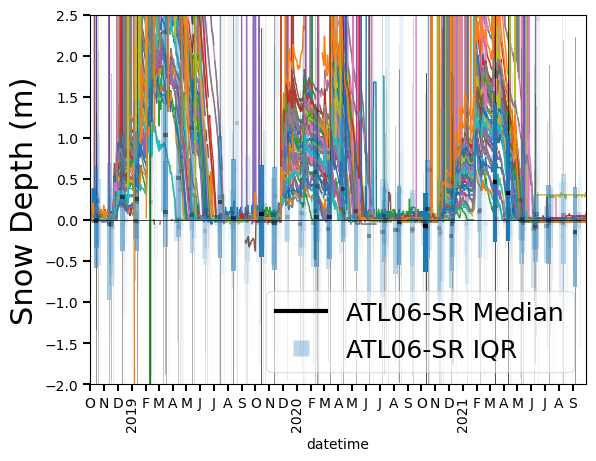

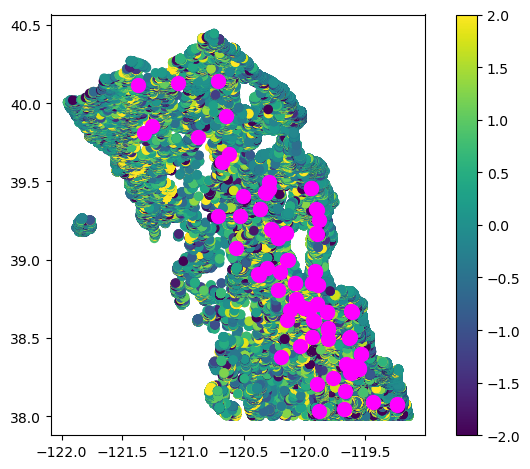

In [94]:
# Plot time series of ICESat-2 and in-situ snow depth:

df = atl06sr_gdf.clip(north_sierras_gdf.to_crs(atl06sr_gdf.crs).geometry)
df = df.loc[(df['slope']<20) & (~df['segment_landcover'].isin(canopy_codes))]
groupby_col='acqdate'
col='icesat2_3dep_dif'
#poly = huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')]

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2.5)

fig, ax = plt.subplots()

north_stations_sd_df_2018_2021.plot(ax=ax, alpha=1,  lw=1, legend=True)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='lower right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')

# Plot location of snow depth in-situ stations with IS2 track locations:

fig, ax = plt.subplots()

df.plot(column='icesat2_3dep_dif', ax=ax, vmin=-2, vmax=2, legend=True)
#poly.plot(ax=ax, facecolor='none', edgecolor='k')
north_stations.plot(ax=ax, markersize = 100, c='magenta', legend=True)

plt.tight_layout()

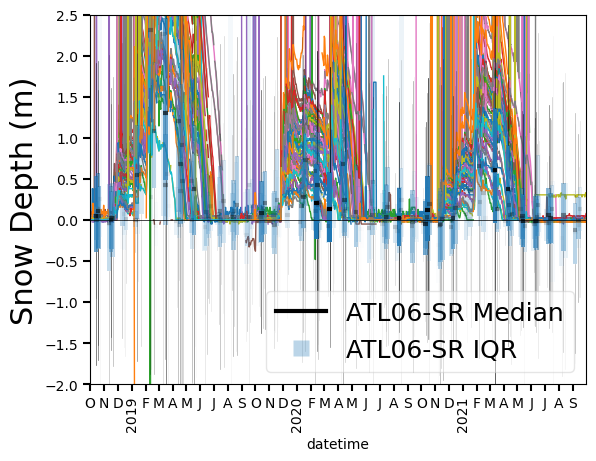

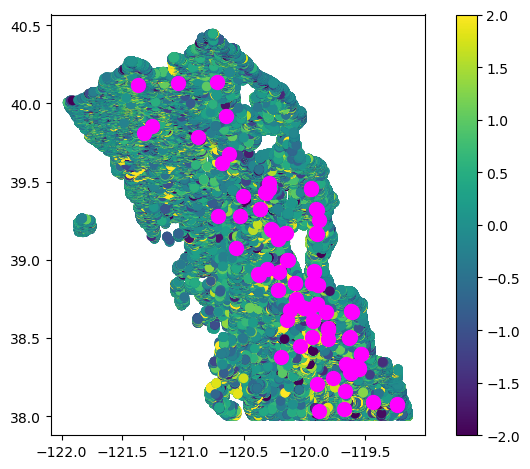

In [95]:
# Plot time series of ICESat-2 and in-situ snow depth:

df = atl06sr_gdf.clip(north_sierras_gdf.to_crs(atl06sr_gdf.crs).geometry)
df = df[df['slope']<10]
groupby_col='acqdate'
col='icesat2_3dep_dif'
#poly = huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')]

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2.5)

fig, ax = plt.subplots()

north_stations_sd_df_2018_2021.plot(ax=ax, alpha=1,  lw=1, legend=True)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='lower right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')

# Plot location of snow depth in-situ stations with IS2 track locations:

fig, ax = plt.subplots()

df.plot(column='icesat2_3dep_dif', ax=ax, vmin=-2, vmax=2, legend=True)
#poly.plot(ax=ax, facecolor='none', edgecolor='k')
north_stations.plot(ax=ax, markersize = 100, c='magenta', legend=True)

plt.tight_layout()

In [91]:
# Separate the stations into north and south, with latitude 38 as the cutoff based on Jessica's EOF analysis

from shapely.geometry import box

# Define bounding box coordinates (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = -121.948903, 34.818611, -117.862654, 38
# Create the polygon
bbox_polygon = box(minx, miny, maxx, maxy)
# Make a polygon into a dataframe so it can have a crs
south_sierras_gdf = gpd.GeoDataFrame(geometry=[bbox_polygon], crs='EPSG:4326')


# Clip the stations to the northern section of the Sierras
south_stations = sierra_stations.clip(south_sierras_gdf.geometry)

# Make a list of the codes
south_station_codes = list(south_stations.index.values)

#Download the snow depth data for the stations with those codes
station_dict = {}

for station in south_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

south_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()

# Subset the stations to WY 2021
south_stations_sd_df_2018_2021 = south_stations_sd_df.loc['2018-10-01':'2021-09-30']

In [96]:
# Plot time series of ICESat-2 and in-situ snow depth:

df = atl06sr_gdf.clip(south_sierras_gdf.to_crs(atl06sr_gdf.crs).geometry)
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
groupby_col='acqdate'
col='icesat2_3dep_dif'
#poly = huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')]

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2.5)

fig, ax = plt.subplots()

south_stations_sd_df_2018_2021.plot(ax=ax, alpha=1,  lw=1, legend=True)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='lower right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')

# Plot location of snow depth in-situ stations with IS2 track locations:

fig, ax = plt.subplots()

df.plot(column='icesat2_3dep_dif', ax=ax, vmin=-2, vmax=2, legend=True)
#poly.plot(ax=ax, facecolor='none', edgecolor='k')
south_stations.plot(ax=ax, markersize = 100, c='magenta', legend=True)

plt.tight_layout()

NameError: name 'south_sierras_gdf' is not defined

### American River:

In [97]:
basin_stations = all_stations_gdf.clip((huc8_sierra[huc8_sierra['name'].str.contains('American')].geometry.to_crs(all_stations_gdf.crs)))

basin_station_codes = list(basin_stations.index.values)

station_dict = {}

for station in basin_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

basin_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()

basin_stations_sd_df_2018_2021 = basin_stations_sd_df.loc['2018-10-01':'2021-09-30']

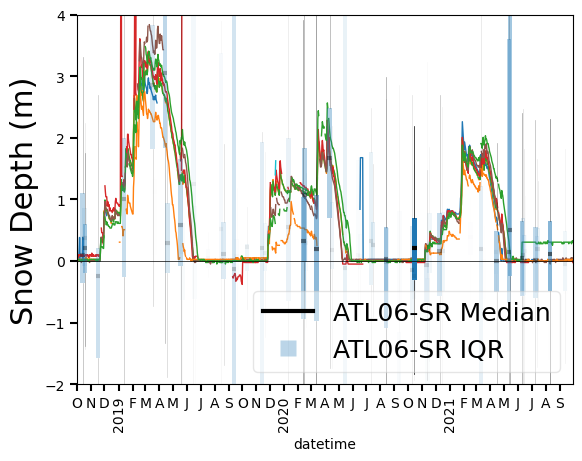

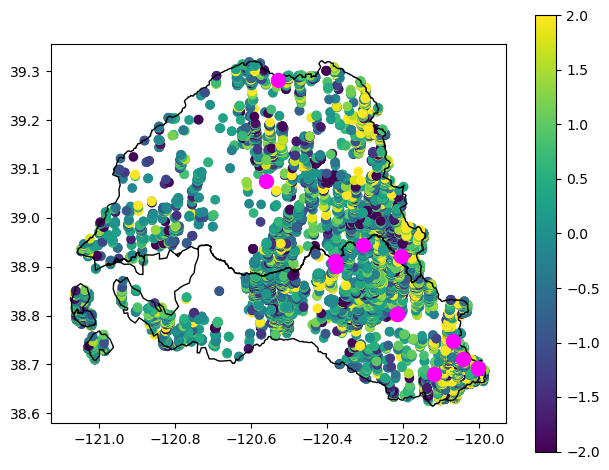

In [100]:
# Access snow depth stations within basin:
basin = 'American'

basin_stations = all_stations_gdf.clip((huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(all_stations_gdf.crs)))

basin_station_codes = list(basin_stations.index.values)

station_dict = {}

for station in basin_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

basin_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()

basin_stations_sd_df_2021 = basin_stations_sd_df.loc['2018-10-01':'2021-09-30']


# Plot time series of ICESat-2 and in-situ snow depth:

df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<20) & (~df['segment_landcover'].isin(canopy_codes))]
groupby_col='acqdate'
col='icesat2_3dep_dif'
poly = huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')]

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 4)

fig, ax = plt.subplots()

basin_stations_sd_df_2018_2021.plot(ax=ax, alpha=1,  lw=1, legend=True)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='lower right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')

# Plot location of snow depth in-situ stations with IS2 track locations:

fig, ax = plt.subplots()

df.plot(column='icesat2_3dep_dif', ax=ax, vmin=-2, vmax=2, legend=True)
poly.plot(ax=ax, facecolor='none', edgecolor='k')
basin_stations.plot(ax=ax, markersize = 100, c='magenta', legend=True)

plt.tight_layout()

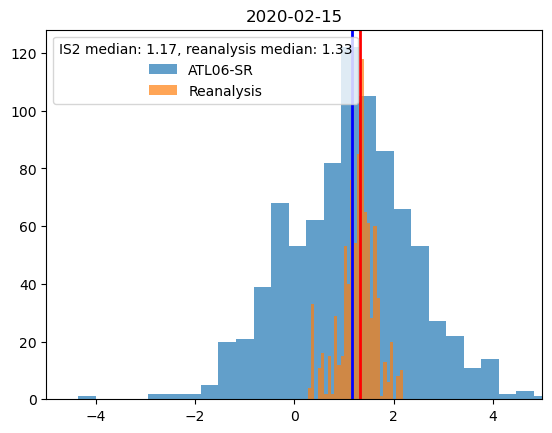

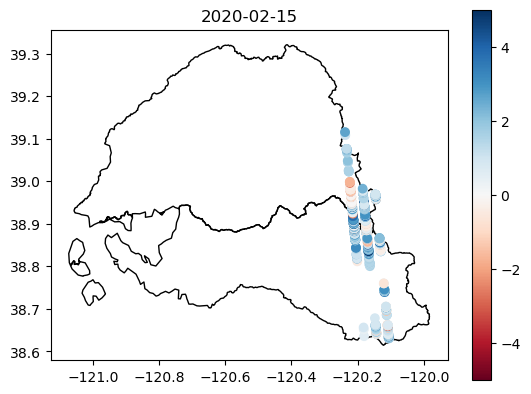

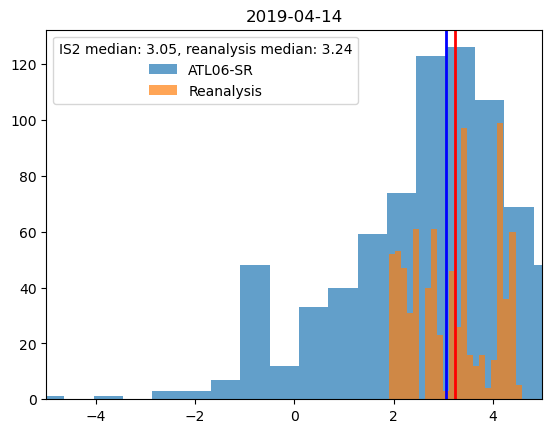

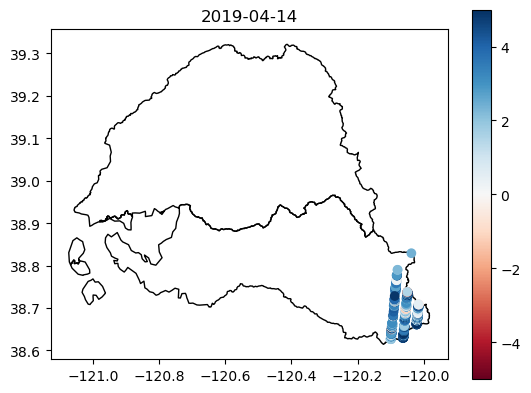

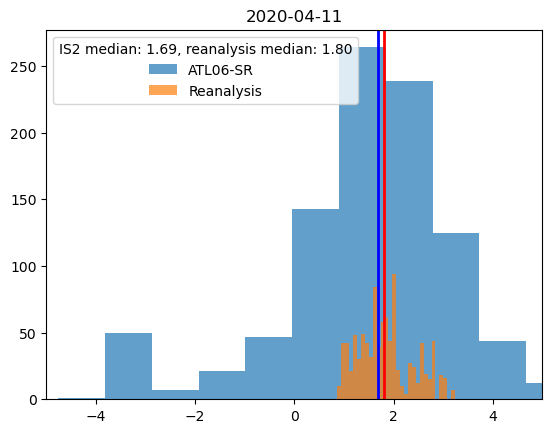

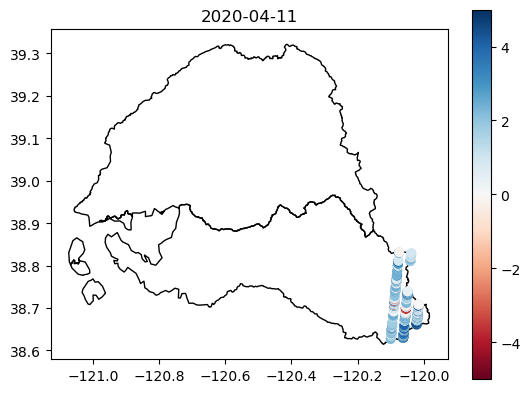

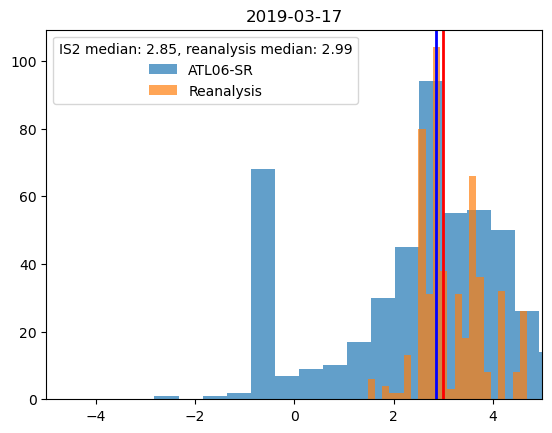

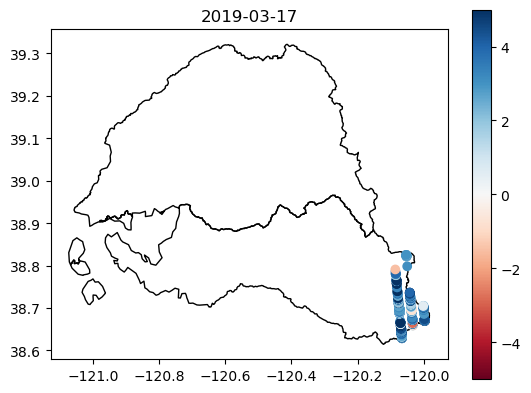

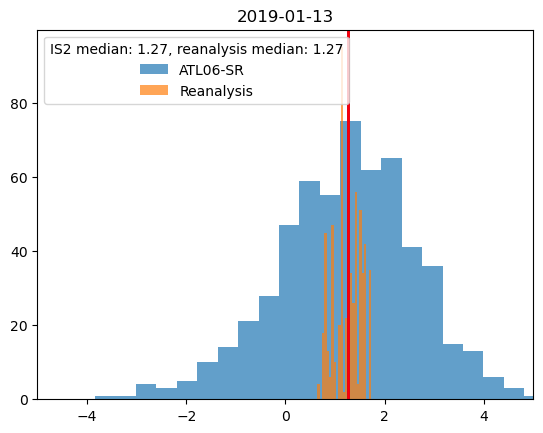

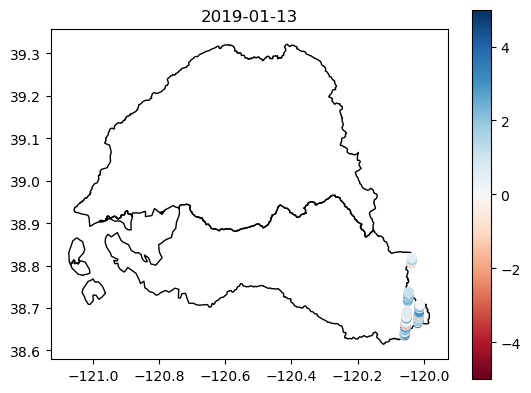

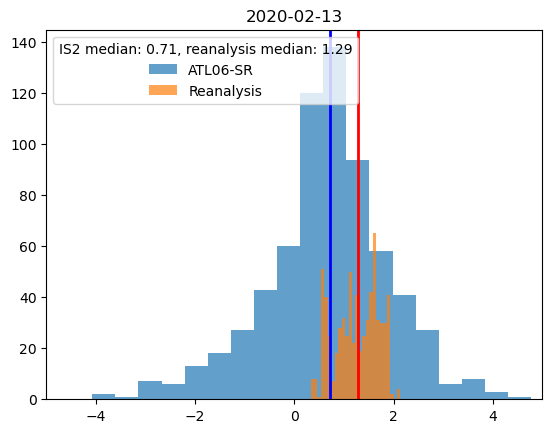

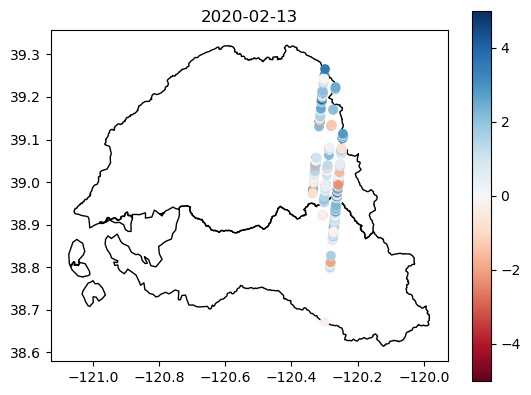

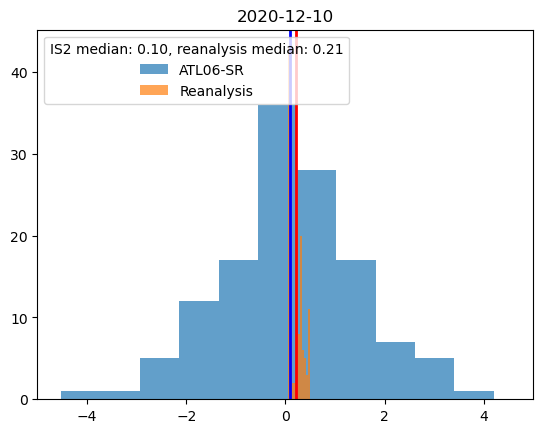

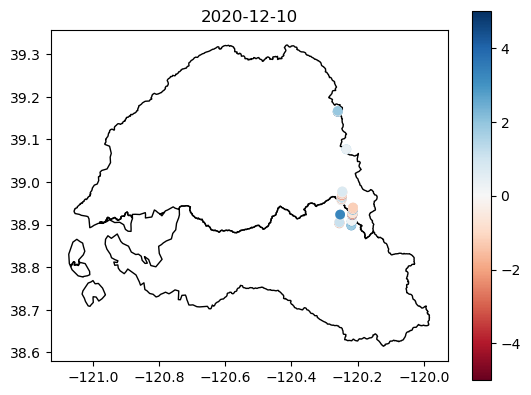

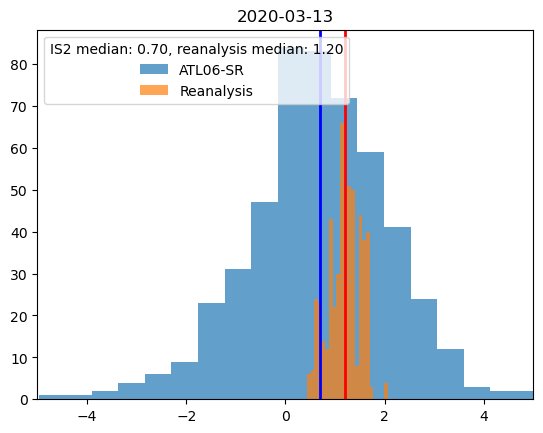

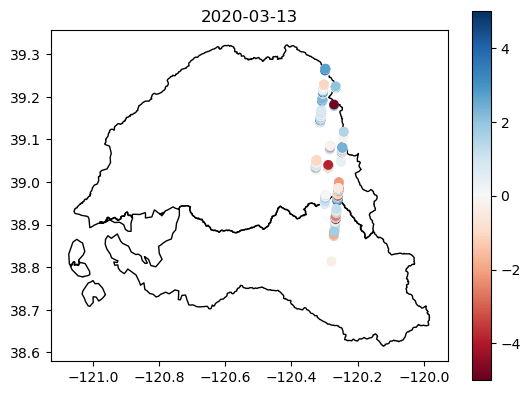

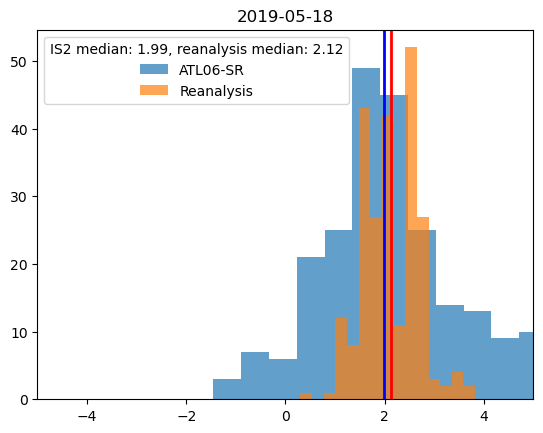

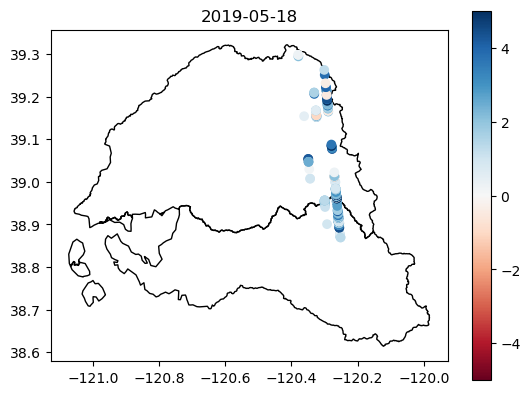

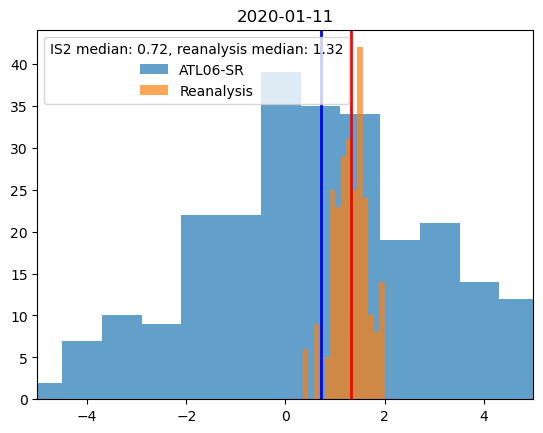

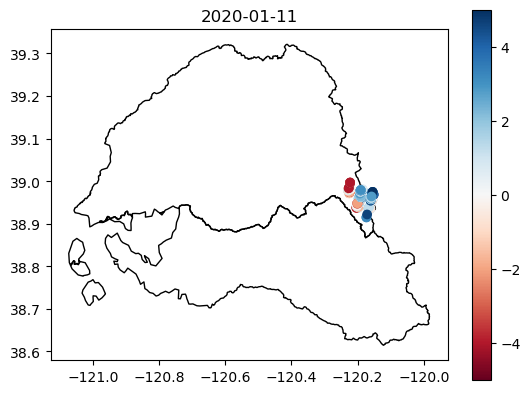

In [101]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('American')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<20) & (~df['segment_landcover'].isin(canopy_codes))]
snow_column='icesat2_3dep_dif'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('American')]


for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_sca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_sca']>0.9)]['reanalysis_sd']

    if int(np.sqrt(len(atl06_subset))) > 10:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len(atl06_subset))), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_sca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

### Tuolumne Basin:

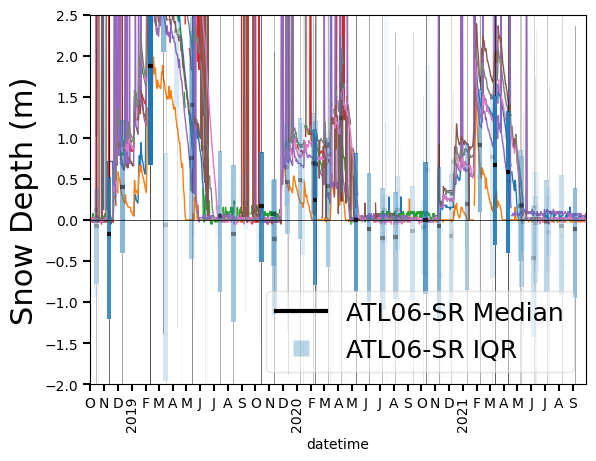

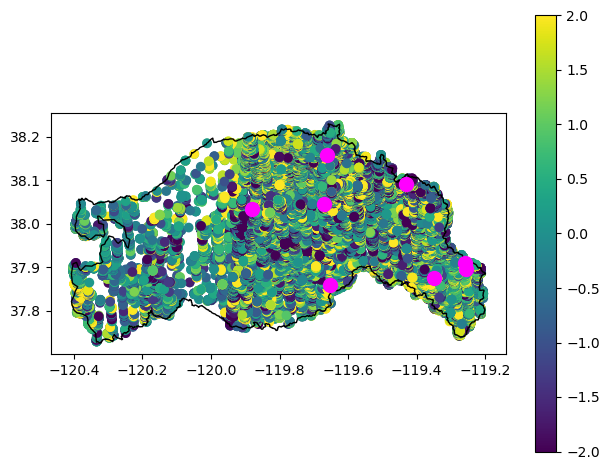

In [105]:
# Access snow depth stations within basin:
basin = 'Tuolumne'

basin_stations = all_stations_gdf.clip((huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(all_stations_gdf.crs)))

basin_station_codes = list(basin_stations.index.values)

station_dict = {}

for station in basin_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

basin_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()
basin_stations_sd_df_2021 = basin_stations_sd_df.loc['2018-10-01':'2021-09-30']


# Plot time series of ICESat-2 and in-situ snow depth:

df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<20) & (~df['segment_landcover'].isin(canopy_codes))]
groupby_col='acqdate'
col='icesat2_3dep_dif'
poly = huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')]

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2.5)

fig, ax = plt.subplots()

basin_stations_sd_df_2021.plot(ax=ax, alpha=1,  lw=1, legend=False)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='lower right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')

# Plot location of snow depth in-situ stations with IS2 track locations:

fig, ax = plt.subplots()

df.plot(column='icesat2_3dep_dif', ax=ax, vmin=-2, vmax=2, legend=True)
poly.plot(ax=ax, facecolor='none', edgecolor='k')
basin_stations.plot(ax=ax, markersize = 100, c='magenta', legend=True)

plt.tight_layout()

In [106]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('Tuolumne')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('Tuolumne')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    if int(np.sqrt(len(atl06_subset))) > 10:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len(atl06_subset))), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

KeyError: 'reanalysis_fsca'

<Axes: >

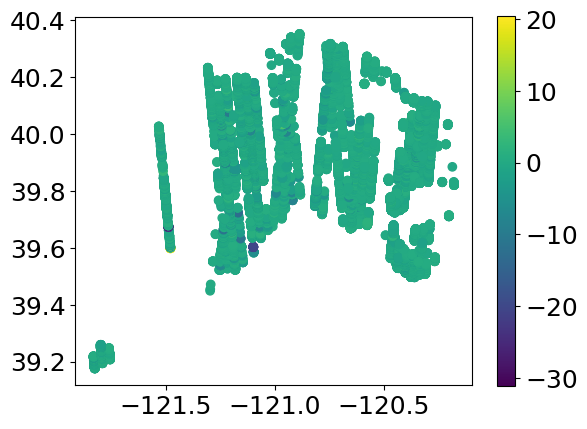

In [205]:
df.plot(column=snow_column, legend=True)

### Feather Basin:

Check where eric is pulling the data. can check cdec website for feather basin.

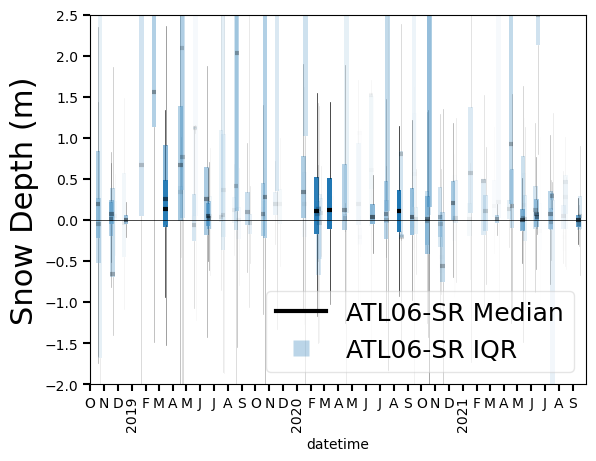

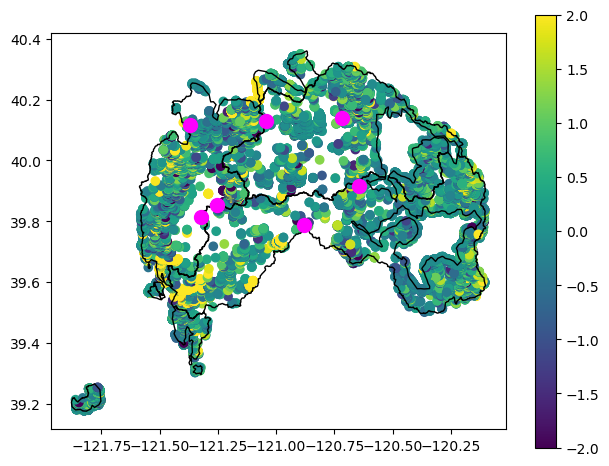

In [108]:
# Access snow depth stations within basin:
# Update basin, only thing that needs to be updated.
basin = 'Feather'

basin_stations = all_stations_gdf.clip((huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(all_stations_gdf.crs)))

basin_station_codes = list(basin_stations.index.values)

station_dict = {}

for station in basin_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

basin_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()
basin_stations_sd_df_2021 = basin_stations_sd_df.loc['2018-10-01':'2021-09-30']


# Plot time series of ICESat-2 and in-situ snow depth:

df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
groupby_col='acqdate'
col='icesat2_3dep_dif'
poly = huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')]

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 2.5)

fig, ax = plt.subplots()

basin_stations_sd_df_2021.plot(ax=ax, alpha=1,  lw=1, legend=False)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='lower right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')

# Plot location of snow depth in-situ stations with IS2 track locations:

fig, ax = plt.subplots()

df.plot(column='icesat2_3dep_dif', ax=ax, vmin=-2, vmax=2, legend=True)
poly.plot(ax=ax, facecolor='none', edgecolor='k')
basin_stations.plot(ax=ax, markersize = 100, c='magenta', legend=True)

plt.tight_layout()

In [183]:
basin_stations_sd_df_2021

,PLP,FOR,BKL,GRZ,HMB,RTL,KTL
datetime,,,,,,,
2020-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-10-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2021-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN


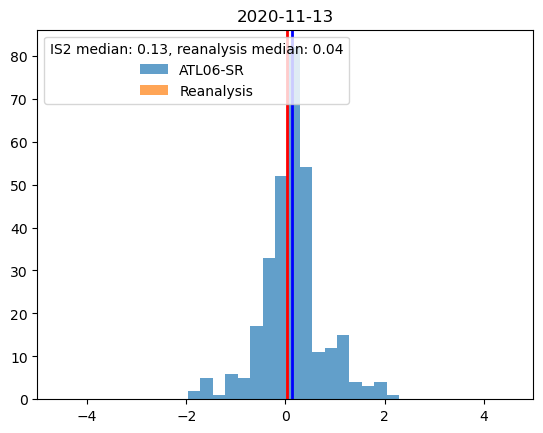

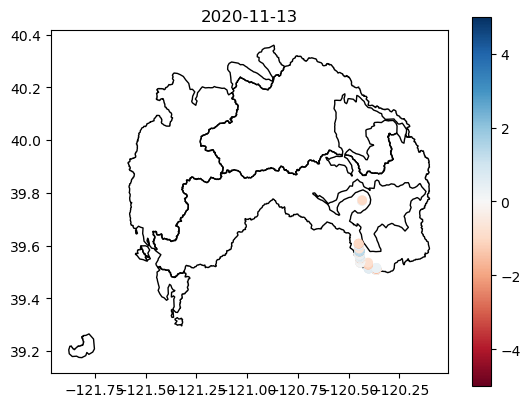

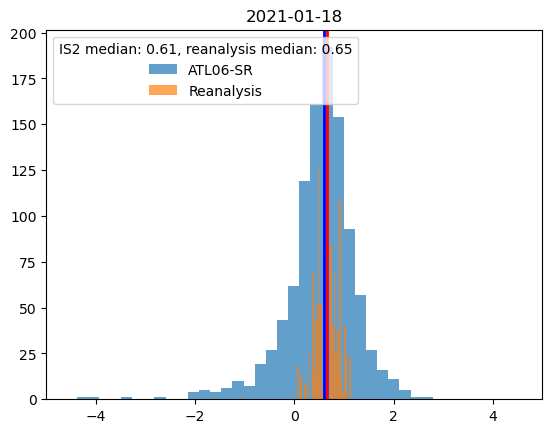

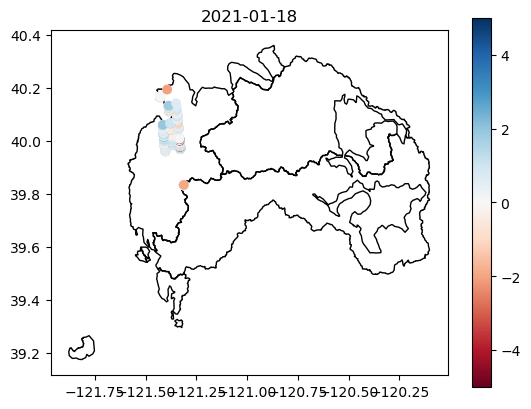

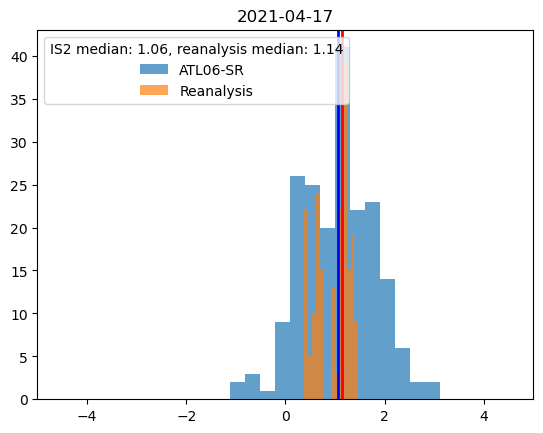

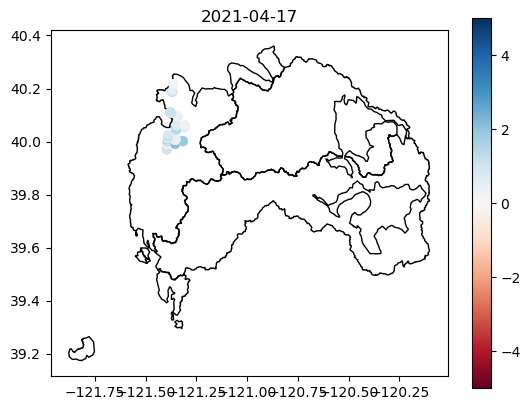

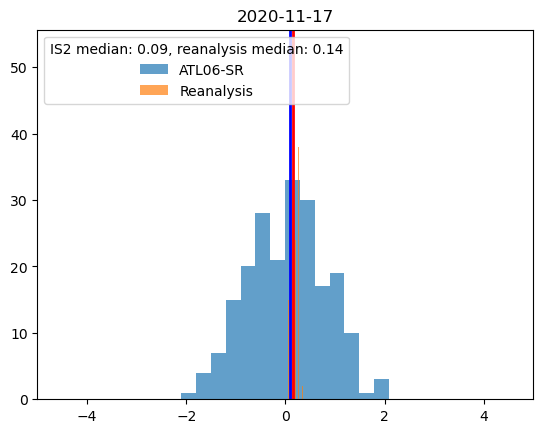

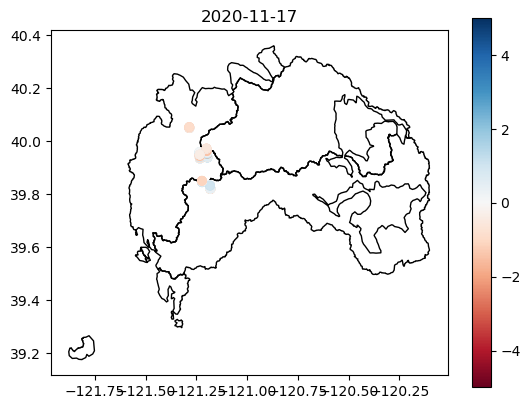

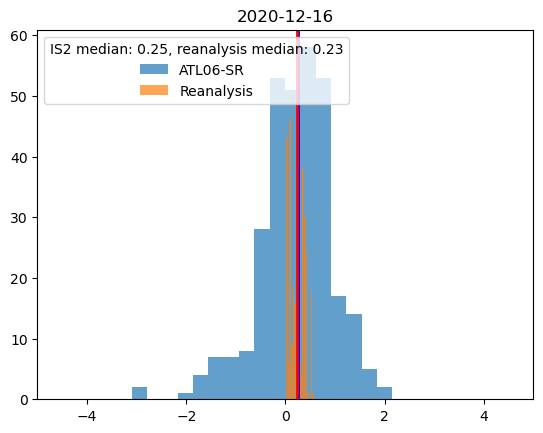

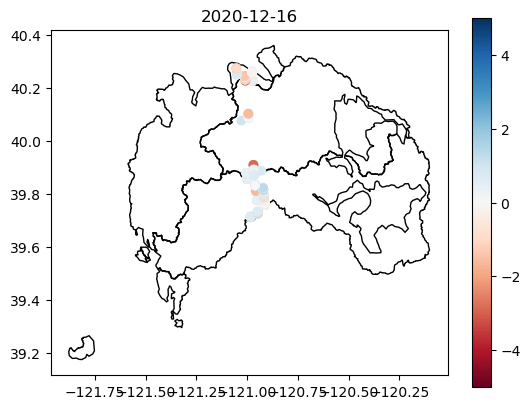

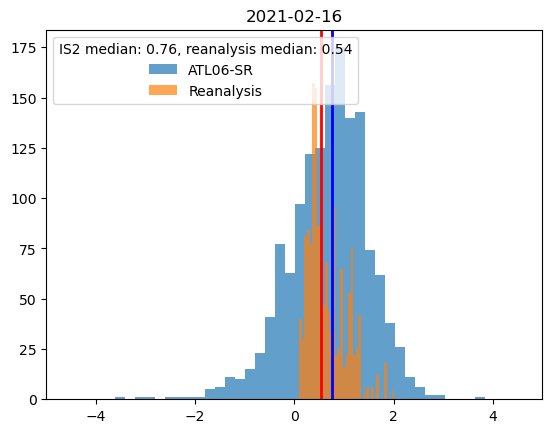

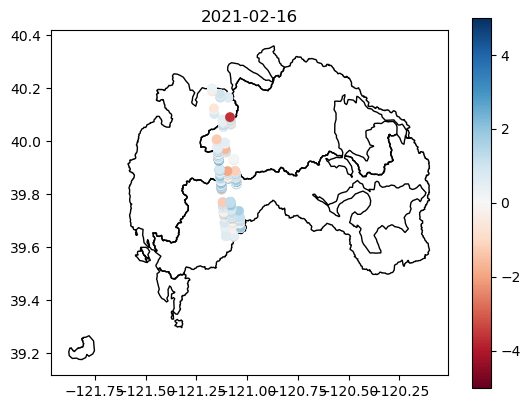

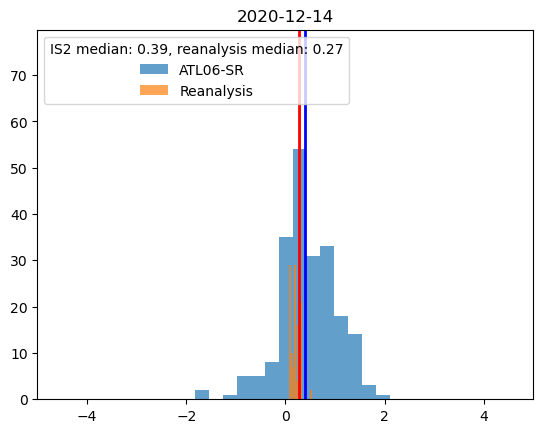

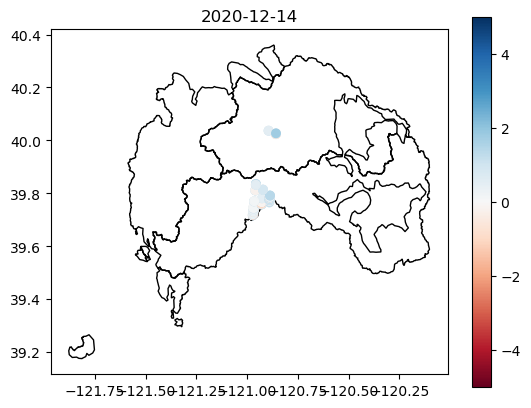

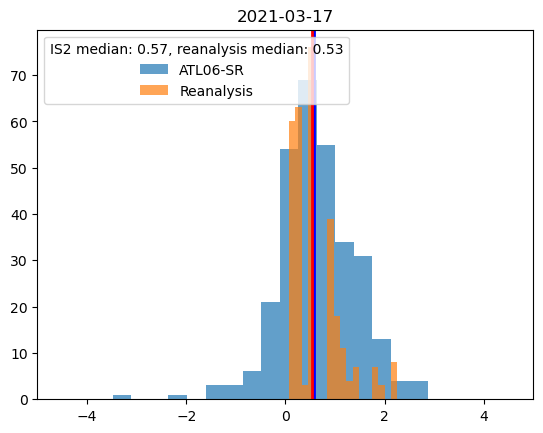

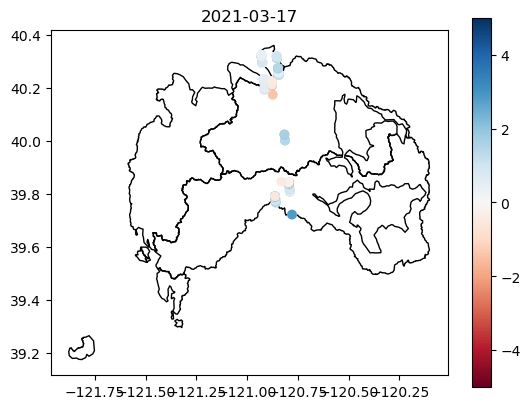

In [226]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('Feather')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('Feather')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    len_atl06_subset = len(atl06_subset[~np.isnan(atl06_subset)])

    if int(np.sqrt(len_atl06_subset)) > 10:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len_atl06_subset)), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset[~np.isnan(reanalysis_subset)]))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

### Yuba River:

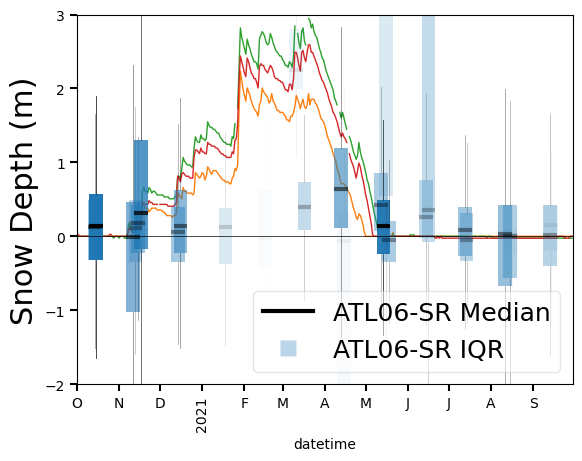

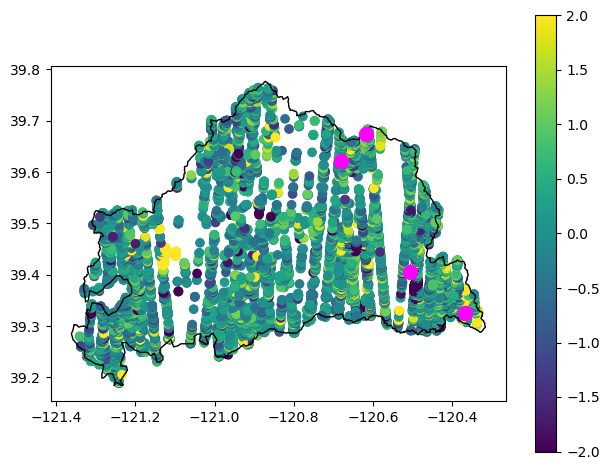

In [227]:
# Access snow depth stations within basin:
# Update basin, only thing that needs to be updated.
basin = 'Yuba'

basin_stations = all_stations_gdf.clip((huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(all_stations_gdf.crs)))

basin_station_codes = list(basin_stations.index.values)

station_dict = {}

for station in basin_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

basin_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()
basin_stations_sd_df_2021 = basin_stations_sd_df.loc['2020-10-01':'2021-09-30']


# Plot time series of ICESat-2 and in-situ snow depth:

df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
groupby_col='acqdate'
col='snow_depth_plus'
poly = huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')]

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 3)

fig, ax = plt.subplots()

basin_stations_sd_df_2021.plot(ax=ax, alpha=1,  lw=1, legend=False)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='lower right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')

# Plot location of snow depth in-situ stations with IS2 track locations:

fig, ax = plt.subplots()

df.plot(column='snow_depth_plus', ax=ax, vmin=-2, vmax=2, legend=True)
poly.plot(ax=ax, facecolor='none', edgecolor='k')
basin_stations.plot(ax=ax, markersize = 100, c='magenta', legend=True)

plt.tight_layout()

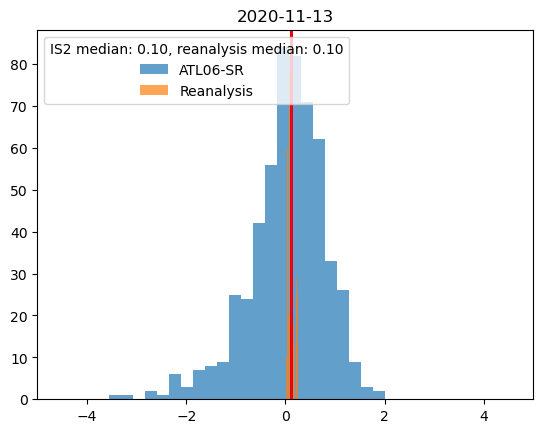

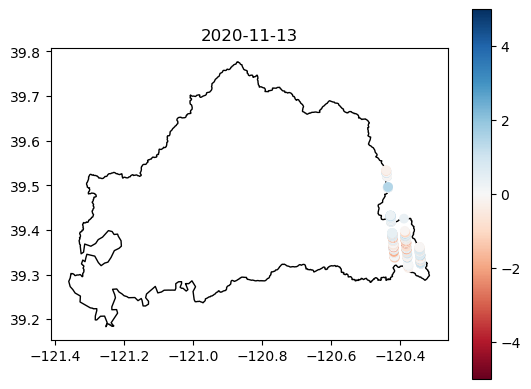

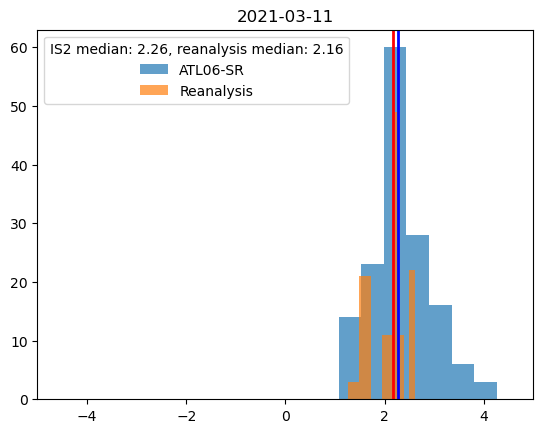

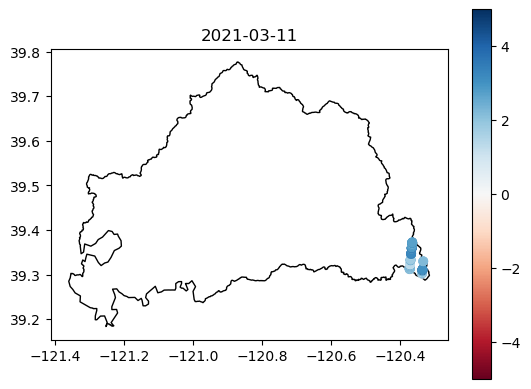

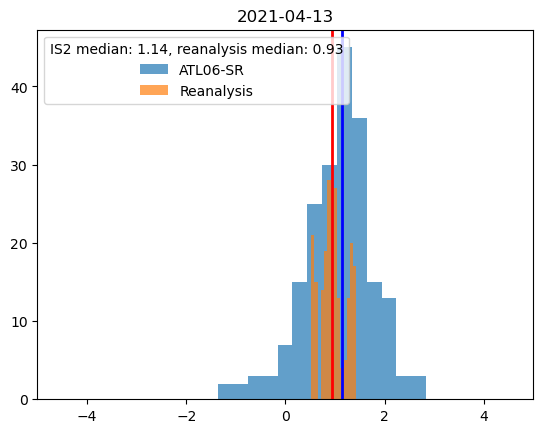

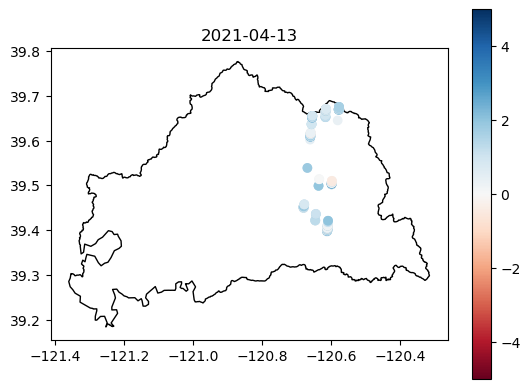

In [228]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('Yuba')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('Yuba')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    len_atl06_subset = len(atl06_subset[~np.isnan(atl06_subset)])

    if int(np.sqrt(len_atl06_subset)) > 10:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len_atl06_subset)), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset[~np.isnan(reanalysis_subset)]))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

For some dates and watersheds, this seems feasible. For others, it doesn't. Waiting on the slope calculations hoping that slope plays a role in determining where we can use IS2. Otherwise, waiting on SR to stabilize the amount of data that gets downloaded over large areas, at which point I'll rerun the download with the additional attributes from the original products to include canopy cover, azimuth angle, landcover type, snowcover, etc. 

## South Sierra:

<Axes: >

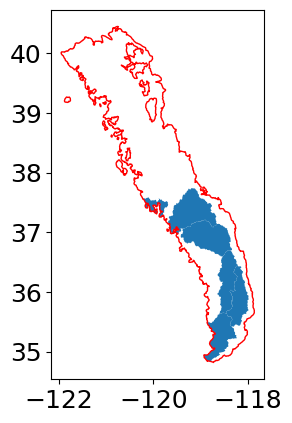

In [ ]:
fig, ax = plt.subplots()
huc8_sierra[(huc8_sierra['name'].str.contains('Kern|San Joaquin|King'))].plot(ax=ax)
sierras.plot(ax=ax, facecolor='none', edgecolor='r')

### Kern River:

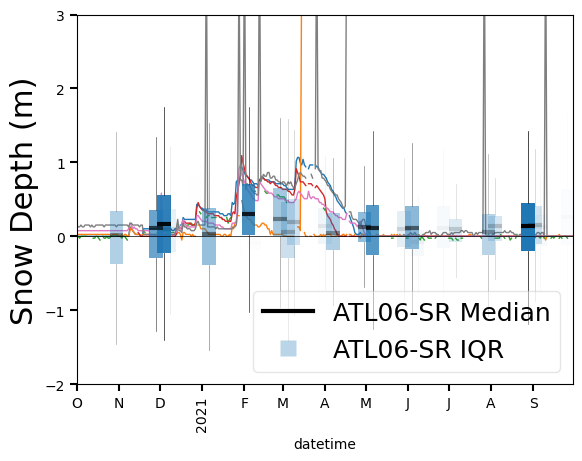

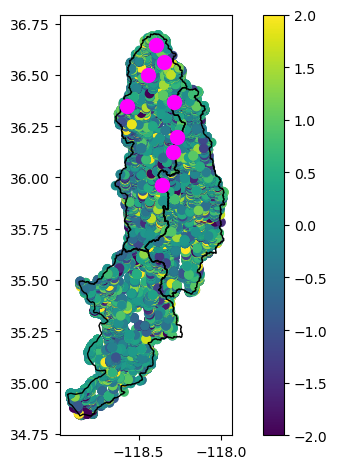

In [229]:
# Access snow depth stations within basin:
# Update basin, only thing that needs to be updated.
basin = 'Kern'

basin_stations = all_stations_gdf.clip((huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(all_stations_gdf.crs)))

basin_station_codes = list(basin_stations.index.values)

station_dict = {}

for station in basin_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

basin_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()
basin_stations_sd_df_2021 = basin_stations_sd_df.loc['2020-10-01':'2021-09-30']


# Plot time series of ICESat-2 and in-situ snow depth:

df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
groupby_col='acqdate'
col='snow_depth_plus'
poly = huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')]

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 3)

fig, ax = plt.subplots()

basin_stations_sd_df_2021.plot(ax=ax, alpha=1,  lw=1, legend=False)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='lower right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')

# Plot location of snow depth in-situ stations with IS2 track locations:

fig, ax = plt.subplots()

df.plot(column='snow_depth_plus', ax=ax, vmin=-2, vmax=2, legend=True)
poly.plot(ax=ax, facecolor='none', edgecolor='k')
basin_stations.plot(ax=ax, markersize = 100, c='magenta', legend=True)

plt.tight_layout()

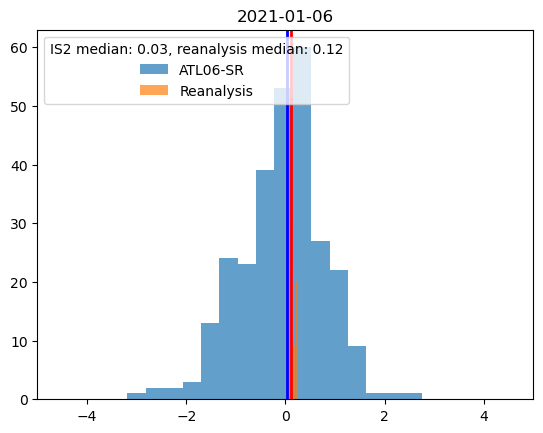

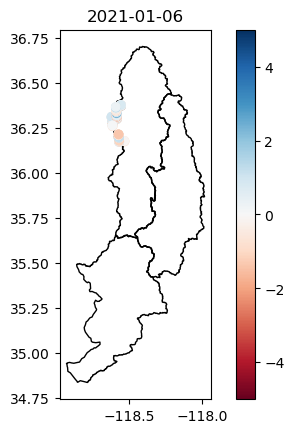

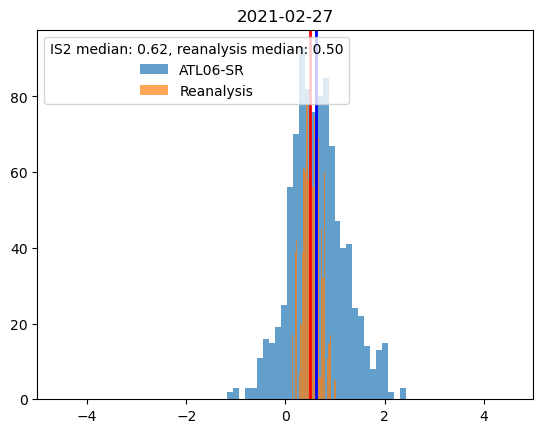

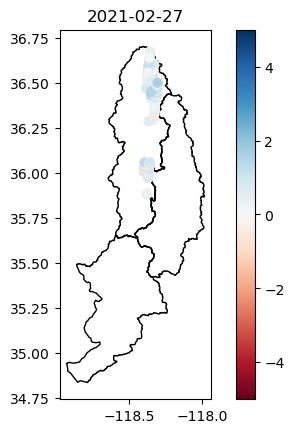

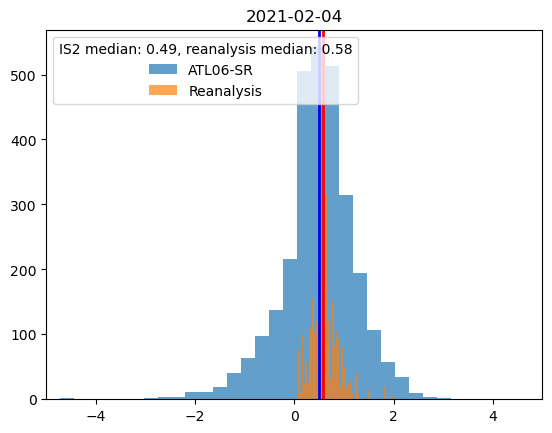

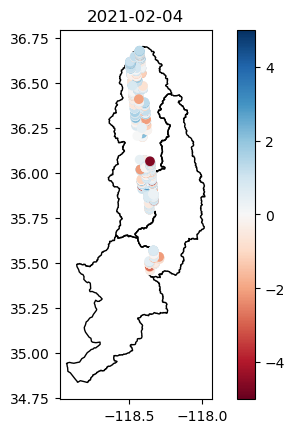

In [230]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('Kern')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('Kern')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    len_atl06_subset = len(atl06_subset[~np.isnan(atl06_subset)])

    if int(np.sqrt(len_atl06_subset)) > 7:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len_atl06_subset)), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset[~np.isnan(reanalysis_subset)]))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

### King River:

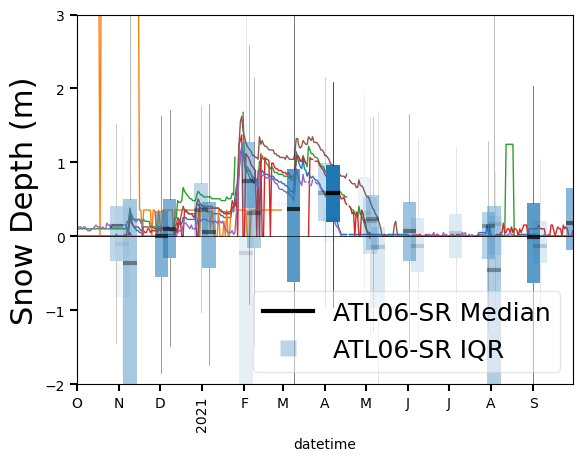

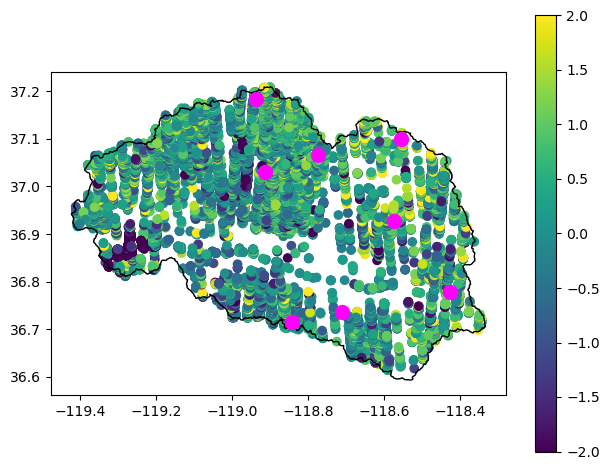

In [231]:
# Access snow depth stations within basin:
# Update basin, only thing that needs to be updated.
basin = 'King'

basin_stations = all_stations_gdf.clip((huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(all_stations_gdf.crs)))

basin_station_codes = list(basin_stations.index.values)

station_dict = {}

for station in basin_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

basin_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()
basin_stations_sd_df_2021 = basin_stations_sd_df.loc['2020-10-01':'2021-09-30']


# Plot time series of ICESat-2 and in-situ snow depth:

df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
groupby_col='acqdate'
col='snow_depth_plus'
poly = huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')]

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 3)

fig, ax = plt.subplots()

basin_stations_sd_df_2021.plot(ax=ax, alpha=1,  lw=1, legend=False)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='lower right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')

# Plot location of snow depth in-situ stations with IS2 track locations:

fig, ax = plt.subplots()

df.plot(column='snow_depth_plus', ax=ax, vmin=-2, vmax=2, legend=True)
poly.plot(ax=ax, facecolor='none', edgecolor='k')
basin_stations.plot(ax=ax, markersize = 100, c='magenta', legend=True)

plt.tight_layout()

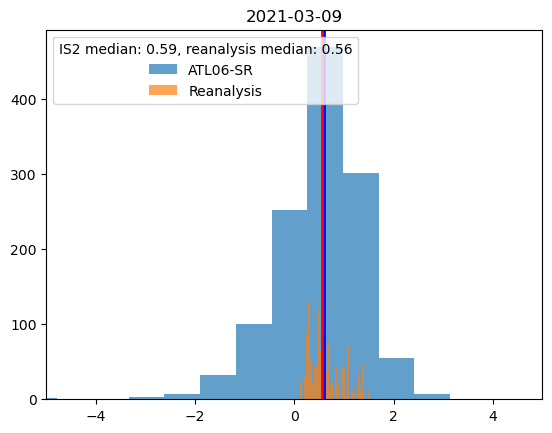

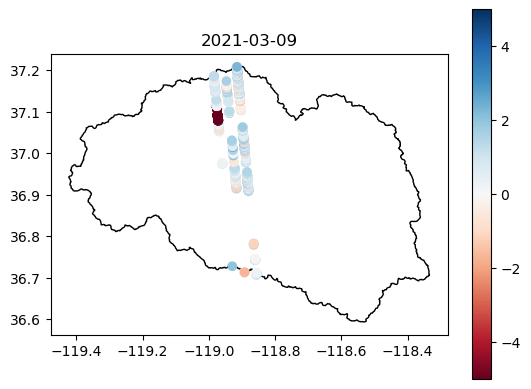

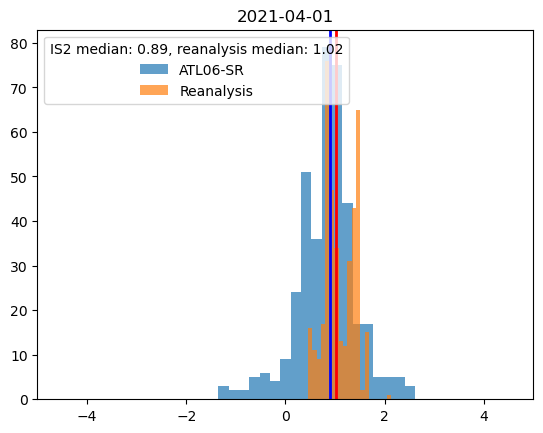

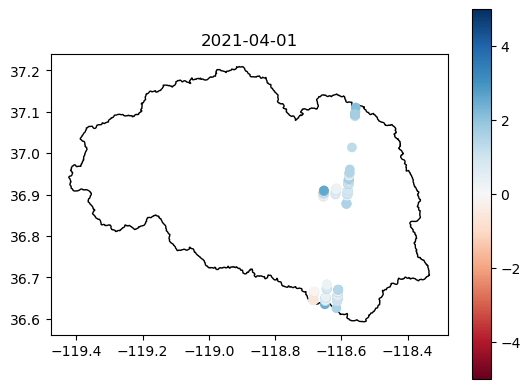

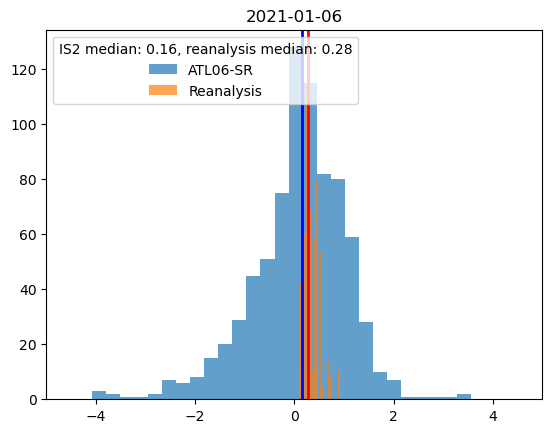

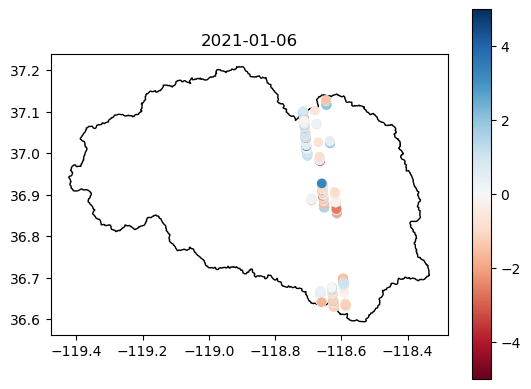

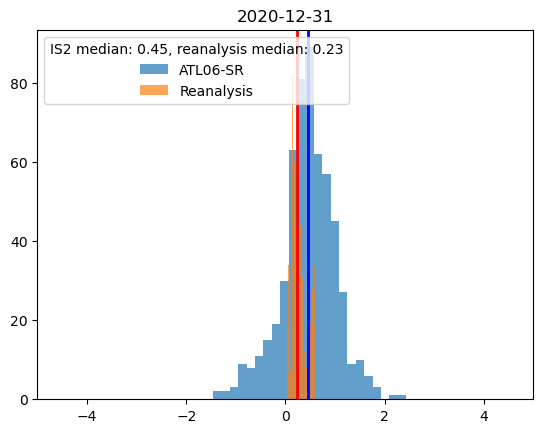

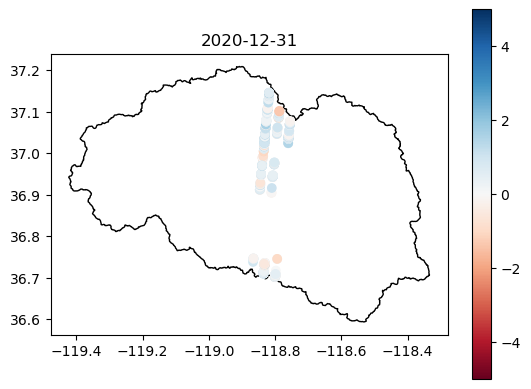

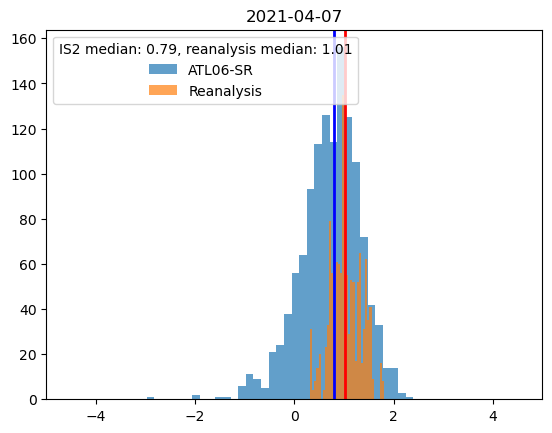

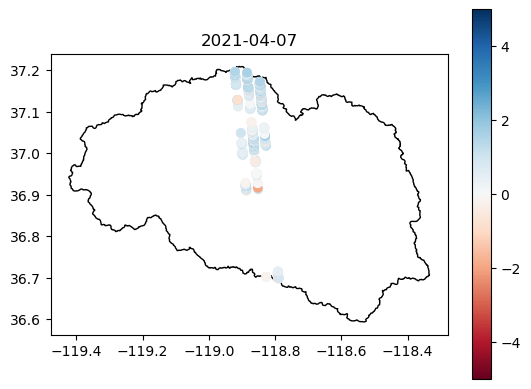

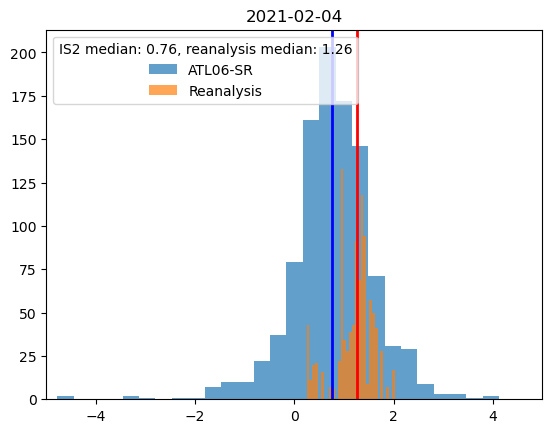

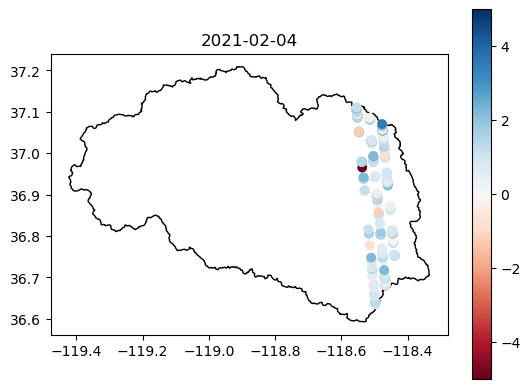

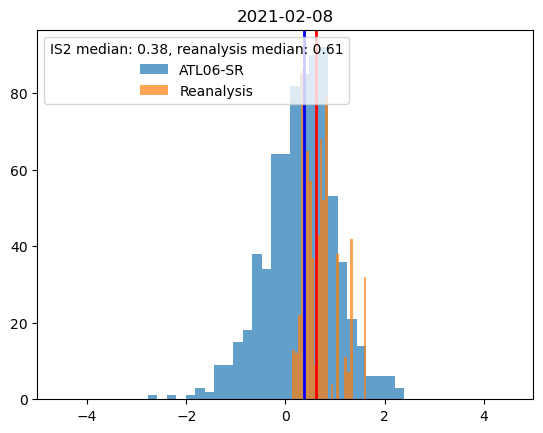

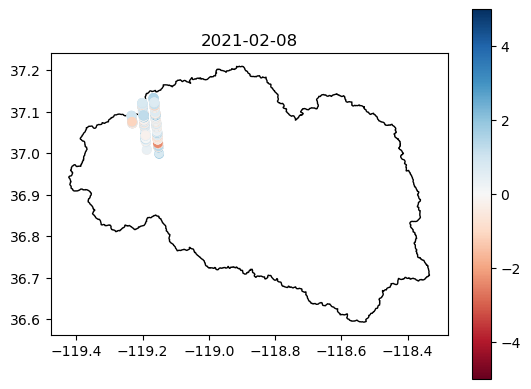

In [232]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('King')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('King')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    len_atl06_subset = len(atl06_subset[~np.isnan(atl06_subset)])

    if int(np.sqrt(len_atl06_subset)) > 7:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len_atl06_subset)), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset[~np.isnan(reanalysis_subset)]))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

### San Joaquin:

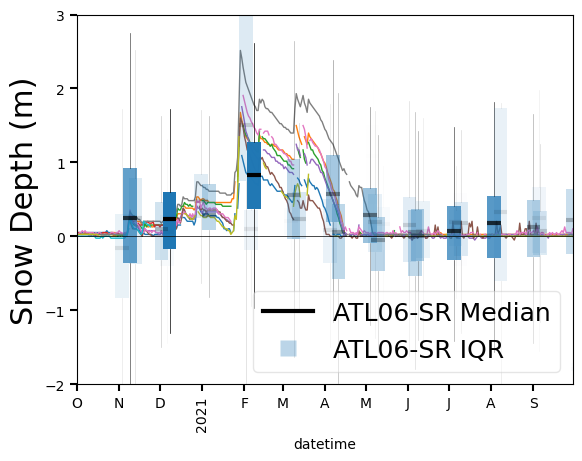

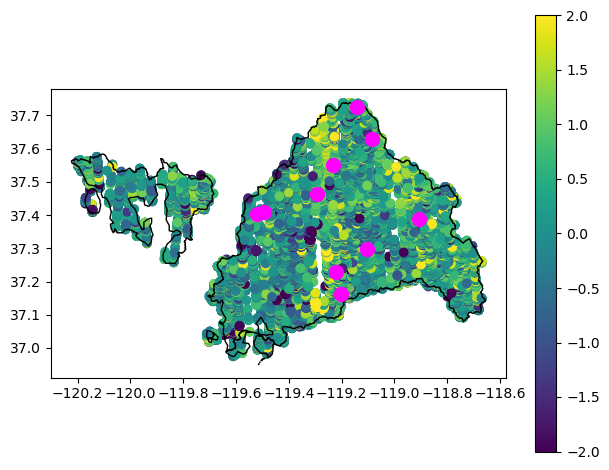

In [233]:
# Access snow depth stations within basin:
# Update basin, only thing that needs to be updated.
basin = 'San Joaquin'

basin_stations = all_stations_gdf.clip((huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(all_stations_gdf.crs)))

basin_station_codes = list(basin_stations.index.values)

station_dict = {}

for station in basin_station_codes:
    tmp = pd.read_csv(f'https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data/{station}.csv',index_col='datetime',parse_dates=True)['SNWD']
    station_dict[station] = tmp

basin_stations_sd_df = pd.DataFrame.from_dict(station_dict)#.dropna()
basin_stations_sd_df_2021 = basin_stations_sd_df.loc['2020-10-01':'2021-09-30']


# Plot time series of ICESat-2 and in-situ snow depth:

df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
groupby_col='acqdate'
col='snow_depth_plus'
poly = huc8_sierra[huc8_sierra['name'].str.contains(f'{basin}')]

bp_stats = df[[col, groupby_col]].dropna().groupby(groupby_col).apply(cbook.boxplot_stats)
bp_stats_list = [i[0] for i in bp_stats.values]
bp_alpha = df[[col, groupby_col]].dropna().groupby(groupby_col).count().values.ravel()
bp_alpha_boxes = bp_alpha/bp_alpha.max()
pos = (pd.to_datetime(bp_stats.index) - pd.to_datetime(mpl_epoch)).days.values

# dt_min_plot = '2020-10-01'
# dt_max_plot = '2021-09-30'
clim = (-2, 3)

fig, ax = plt.subplots()

basin_stations_sd_df_2021.plot(ax=ax, alpha=1,  lw=1, legend=False)

bxp_f = ax.bxp(bp_stats_list, positions=pos, showfliers=False, showcaps=False, 
                   whiskerprops={'lw':0.5, 'alpha':0}, boxprops= {'lw':1, 'alpha':0.2},  
                   medianprops={'lw':3},widths=10, patch_artist=True)

for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_edgecolor('None')
    patch.set_linewidth(0)

for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_color('k')  # or deeppink 

 #set the ATL06SR alpha (transparency) for each box, whisker, and median according to the number of samples for that measurement
for patch, alpha in zip(bxp_f['boxes'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_edgecolor('None')
    patch.set_linewidth(0)
for patch, alpha in zip(bxp_f['medians'], bp_alpha_boxes):
    patch.set_alpha(alpha)
    patch.set_color('k')  # or deeppink
#double the alpha list since there are 2 whiskers per box (https://datagy.io/python-combine-lists/)
for patch, alpha in zip(bxp_f['whiskers'], [item for sublist in zip(bp_alpha_boxes, bp_alpha_boxes) for item in sublist]):
    patch.set_alpha(alpha)

ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Snow Depth (m)', fontsize=22)
ax.set_ylim(*clim)
# ax.set_xlim([dt_min_plot, dt_max_plot])

# X AXIS LABELS     
months = mdates.MonthLocator()
month_fmt = mdates.DateFormatter('%b')

def m_fmt(x, pos=None):
    return month_fmt(x)[0]

ax.xaxis.set_minor_locator(months) 
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))

years = mdates.MonthLocator(bymonth=1)
ax.format_xdata = mdates.DateFormatter('%Y')
years_fmt = mdates.DateFormatter('%Y')
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
ax.tick_params('both', length=5, width=1.5, which='major')
ax.tick_params('both', length=5, width=1.5, which='minor')
ax.legend(custom, custom_labels, loc='lower right', prop={'size':18}, fancybox=True, framealpha=0.5) #, fontsize=10

for label in ax.get_xticklabels(which='major'): #
    label.set(rotation=90, horizontalalignment='center')

# Plot location of snow depth in-situ stations with IS2 track locations:

fig, ax = plt.subplots()

df.plot(column='snow_depth_plus', ax=ax, vmin=-2, vmax=2, legend=True)
poly.plot(ax=ax, facecolor='none', edgecolor='k')
basin_stations.plot(ax=ax, markersize = 100, c='magenta', legend=True)

plt.tight_layout()

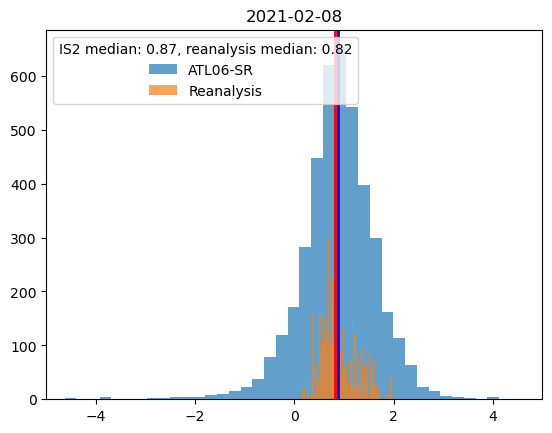

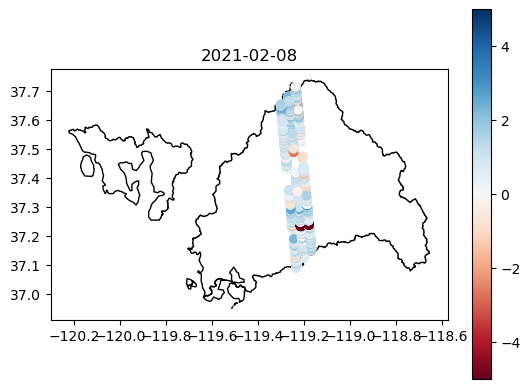

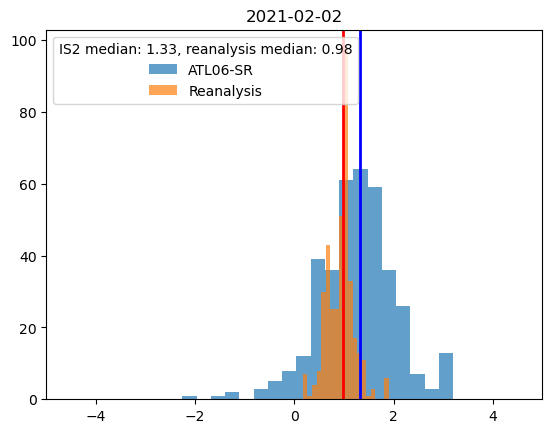

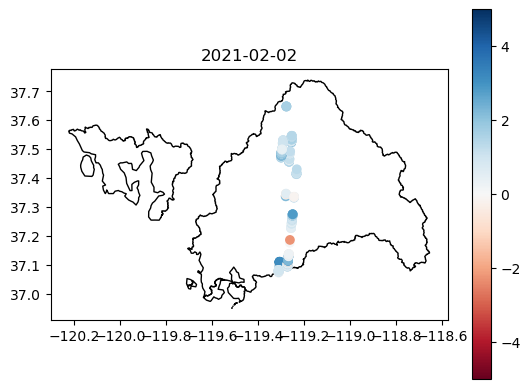

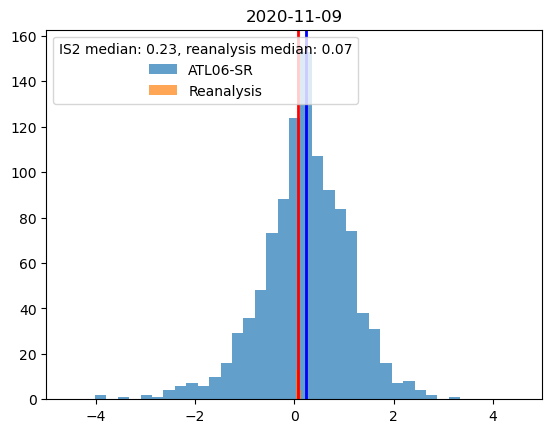

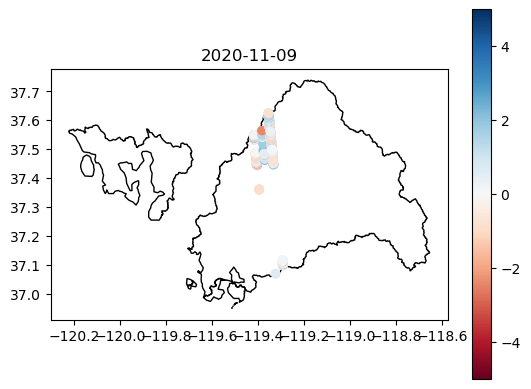

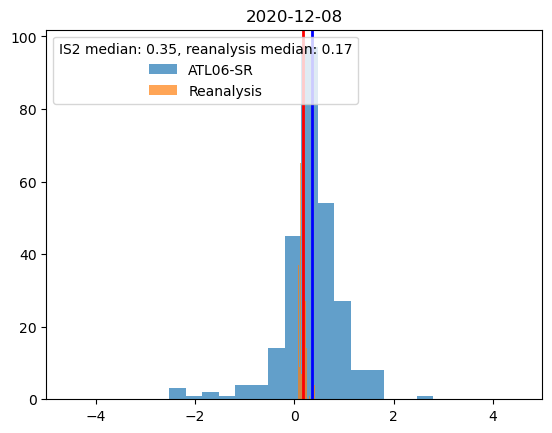

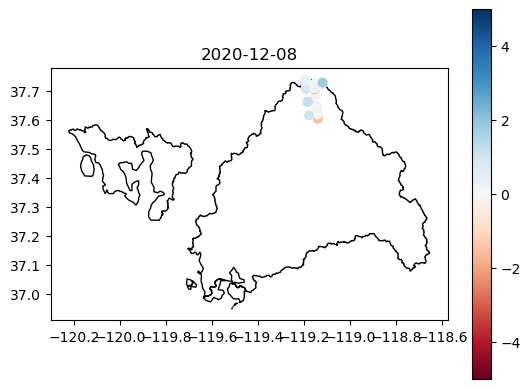

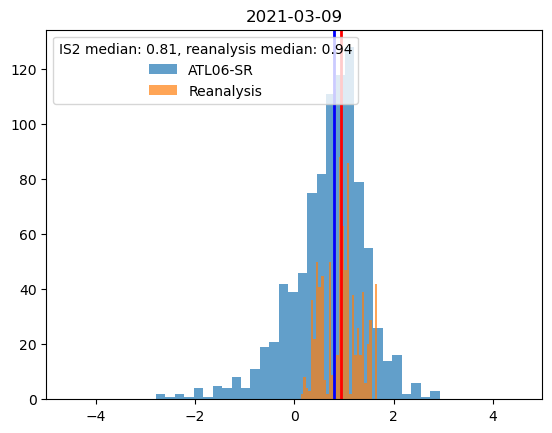

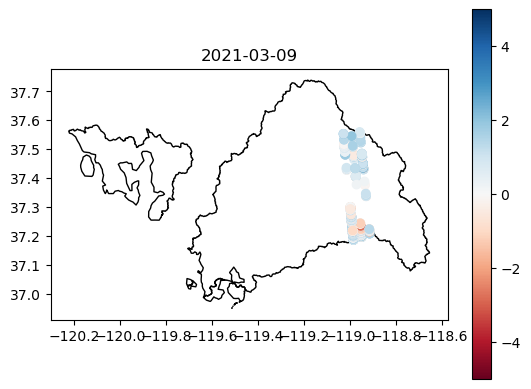

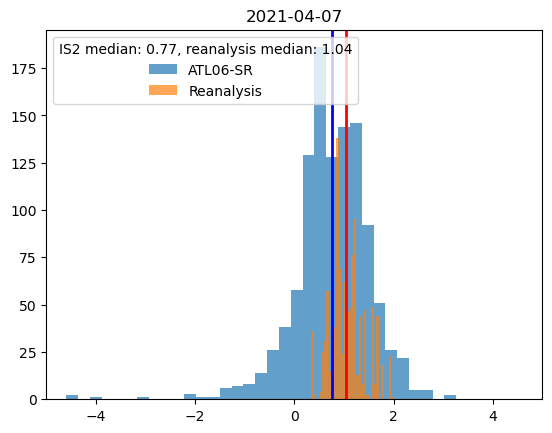

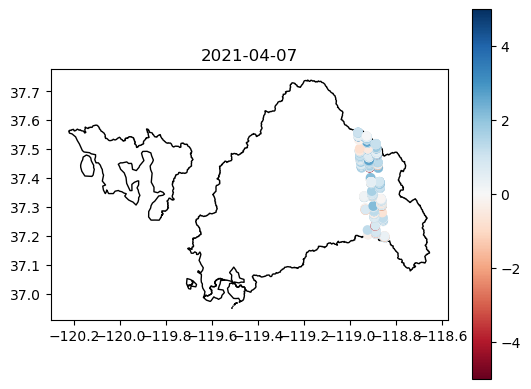

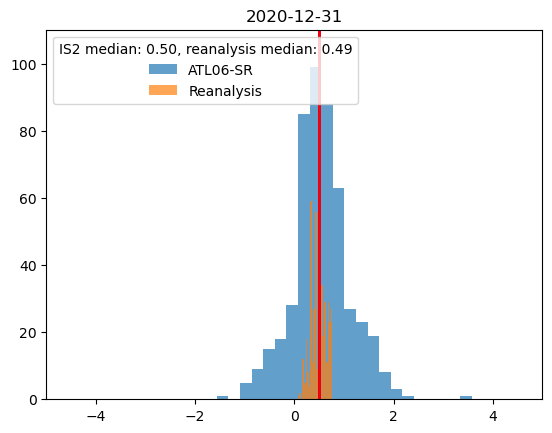

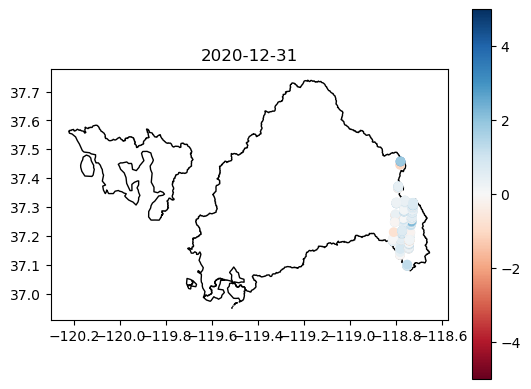

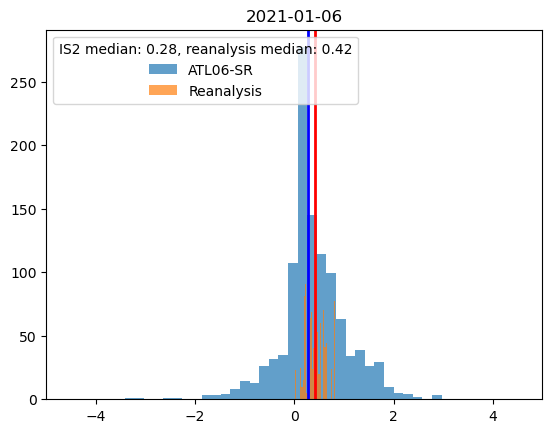

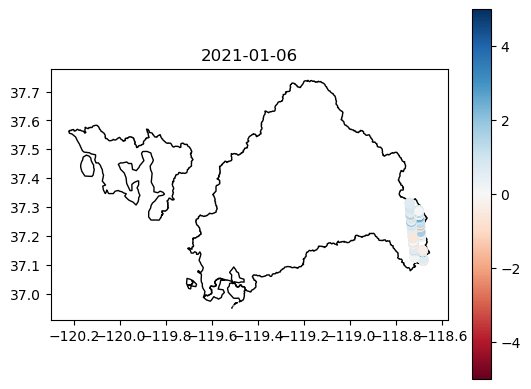

In [234]:
df = atl06sr_gdf.clip(huc8_sierra[huc8_sierra['name'].str.contains('San Joaquin')].geometry.to_crs(atl06sr_gdf.crs))
df = df[(df['slope']<10) & (~df['segment_landcover'].isin(canopy_codes))]
snow_column='snow_depth_plus'
acq_dates = list(df['acqdate'].unique())
poly = huc8_sierra[huc8_sierra['name'].str.contains('San Joaquin')]

for date_index in acq_dates:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    len_atl06_subset = len(atl06_subset[~np.isnan(atl06_subset)])

    if int(np.sqrt(len_atl06_subset)) > 7:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len_atl06_subset)), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset[~np.isnan(reanalysis_subset)]))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{date_index}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

In [190]:
acq_dates_subset = acq_dates[0:2]

for date_index in acq_dates_subset:
    # plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

    atl06_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)][snow_column]
    reanalysis_subset = df.loc[(df['acqdate']==date_index) & (df['reanalysis_fsca']>0.9)]['reanalysis_sd']

    if int(np.sqrt(len(atl06_subset))) > 10:
        fig, ax = plt.subplots()
        ax.hist(atl06_subset, bins=int(np.sqrt(len(atl06_subset))), \
                        alpha=0.7, label='ATL06-SR')
        ax.hist(reanalysis_subset, bins=int(np.sqrt(len(reanalysis_subset))), \
                        alpha=0.7, label='Reanalysis')
        ax.axvline(x = np.nanmedian(atl06_subset), linewidth=2, color='blue')
        ax.axvline(x = np.nanmedian(reanalysis_subset), linewidth=2, color='red')
        plt.xlim(-5, 5)
        plt.title(f'{acq_dates[date_index]}')
        plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06_subset):.2f}, reanalysis median: {np.nanmedian(reanalysis_subset):.2f}')

        
        # Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

        fig, ax = plt.subplots()
        #reanalysis_subset.plot(ax=ax, vmax=2)
        poly.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
        df.loc[(df['acqdate']==date_index)].to_crs('epsg:4326').plot(column=snow_column,ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
        plt.title(f'{date_index}')
        
    else: continue

In [185]:
plot_reanalysis_dif(atl06sr_american, 'snow_depth_plus', huc8_sierra[huc8_sierra['name'].str.contains('American')])

In [ ]:
date_index = 0

# Subset the reanalysis snow depth and fsca data by the IS2 acquisition date:

reanalysis_test = reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]
reanalysis_fsca = fsca_reanalysis_clipped_2019[:,:,atl06sr_gdf[atl06sr_gdf['acqdate']==snowon_dates[date_index]]['dowy'].unique()]

# plot a histogram of the snow-on reanalysis and IS2 data, and display the median values for the basin in the legend title:

fig, ax = plt.subplots()
ax.hist(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic'],\
            bins=250, alpha=0.7, label='ATL06-SR')
ax.hist(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten(),\
            bins=250, alpha=0.7, label='Reanalysis')
ax.axvline(x = np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])]['diff_plus_bicubic']), linewidth=2, color='blue')
ax.axvline(x = np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()), linewidth=2, color='red')
plt.xlim(-5, 5)
plt.title(f'{snowon_dates[date_index]}')
plt.legend(loc='upper left',title=f'IS2 median: {np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index]) & (atl06sr_gdf['reanalysis_fsca']> 0.1)]['diff_plus_bicubic']):.2f}, reanalysis median: {np.nanmedian(reanalysis_test.where(reanalysis_fsca>0.1).values.flatten()):.2f}')

# Plot the reanaysis snow depth where fsca > 0.1, and icesat2 data where fsca > 0.1:

fig, ax = plt.subplots()
reanalysis_test.where(reanalysis_fsca>0.1).plot(ax=ax, vmax=2)
tuol_outline.to_crs('epsg:4326').plot(ax=ax, edgecolor='k', facecolor='none')
atl06sr_gdf.loc[(atl06sr_gdf['acqdate']==snowon_dates[date_index])].to_crs('epsg:4326').plot(column='diff_plus_bicubic',ax=ax, cmap = 'RdBu', legend=True, vmin=-5, vmax=5)
plt.title(f'{snowon_dates[date_index]}')

In [148]:
atl06sr_american['acqdate'].unique()

array([datetime.date(2021, 9, 14), datetime.date(2021, 3, 17),
       datetime.date(2021, 10, 12), datetime.date(2020, 11, 13),
       datetime.date(2021, 7, 14), datetime.date(2021, 8, 11),
       datetime.date(2020, 11, 11), datetime.date(2021, 4, 13),
       datetime.date(2021, 4, 15), datetime.date(2021, 5, 12),
       datetime.date(2021, 3, 11)], dtype=object)

In [149]:
huc10_sierra[huc10_sierra['name'].str.contains('Feather')]

,tnmid,metasource,sourcedata,sourceorig,sourcefeat,loaddate,referenceg,areaacres,areasqkm,states,huc10,name,hutype,humod,shape_Leng,shape_Area,ObjectID,geometry
146,{77CD01A6-8296-44B0-B32C-0F896C33038E},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,223423,47295.36,191.40,CA,1802015902,Upper Feather River,S,None,NaN,NaN,768,"POLYGON ((-121.52069 39.59876, -121.52081 39.5..."
192,{F8A8CD90-59FB-4728-A3CD-37B0A76ABCCB},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,267458,100575.15,407.01,CA,1802012306,South Fork Feather River,S,None,NaN,NaN,833,"POLYGON ((-120.87941 39.78725, -120.87863 39.7..."
193,{03A9A4C3-3040-4428-BED2-E0C5BDA05A40},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,263528,155671.65,629.98,CA,1802012307,Lower Middle Fork Feather River,S,None,NaN,NaN,529,"MULTIPOLYGON (((-121.26302 39.85644, -121.2622..."
194,{12A3398E-B387-4A38-9BCE-6B3D642FB637},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,264163,79255.20,320.73,CA,1802012108,Lower North Fork Feather River,S,None,NaN,NaN,542,"MULTIPOLYGON (((-121.45314 39.81806, -121.4527..."
195,{DF48F8E6-98FA-4923-8257-E3319F9F2DEF},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,268869,107271.42,434.11,CA,1802012107,West Branch Feather River,S,None,NaN,NaN,575,"MULTIPOLYGON (((-121.43995 40.09325, -121.4392..."
196,{E6F42CC1-04A2-49D7-9B01-52D4AC741607},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,264163,133103.94,538.65,CA,1802012106,Middle North Fork Feather River,S,None,NaN,NaN,400,"POLYGON ((-121.31974 40.05764, -121.31931 40.0..."
198,{C13B6EFE-32C2-4763-99DF-D25491302B9D},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,266674,48947.35,198.08,CA,1802012209,East Branch North Fork Feather River,S,None,NaN,NaN,182,"POLYGON ((-121.0309 40.13278, -121.02982 40.13..."
204,{50FACE42-3B73-4201-B81A-56073F214F0A},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,263528,151508.10,613.13,CA,1802012304,Upper Middle Fork Feather River,S,None,NaN,NaN,584,"POLYGON ((-120.59397 39.96165, -120.59293 39.9..."
205,{BA2BEAB0-9E60-43C5-9355-928AF28DE5D6},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,263528,130759.11,529.16,CA,1802012305,Middle Middle Fork Feather River,S,None,NaN,NaN,808,"POLYGON ((-120.68033 39.92166, -120.67978 39.9..."
219,{EF81ABAE-3CA7-4F06-84A6-4A563A1A9FD1},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,264163,157387.95,636.93,CA,1802012104,Upper North Fork Feather River,S,None,NaN,NaN,352,"MULTIPOLYGON (((-121.08936 40.28819, -121.0886..."


In [157]:
huc10_sierra[huc10_sierra['name'].str.contains('Tuolumne')]

,tnmid,metasource,sourcedata,sourceorig,sourcefeat,loaddate,referenceg,areaacres,areasqkm,states,huc10,name,hutype,humod,shape_Leng,shape_Area,ObjectID,geometry
110,{18A91BF2-F0D8-4C53-90F0-D9A869652C1D},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,255171,46733.84,189.13,CA,1804000906,Middle Tuolumne River,S,NM,NaN,NaN,524,"POLYGON ((-119.74807 37.9346, -119.74753 37.93..."
111,{A5662066-ACCE-4142-8935-EA2D0A5BEC5F},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,255171,136808.96,553.65,CA,1804000901,Headwaters Tuolumne River,S,NM,NaN,NaN,424,"POLYGON ((-119.37625 38.09402, -119.37597 38.0..."
114,{F470A198-5CF4-4F9A-812D-48420DE0AAA7},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"260042,255171",123894.68,501.38,CA,1804000905,Falls Creek-Tuolumne River,S,RS,NaN,NaN,126,"POLYGON ((-119.58861 38.18564, -119.58793 38.1..."
119,{A6BD119A-6E56-4F9A-A8E2-9D514A49C833},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"228884,255171",107276.50,434.13,CA,1804000912,Moccasin Creek-Tuolumne River,S,"RS,PD,RC,WD",NaN,NaN,934,"POLYGON ((-120.26794 37.94785, -120.26813 37.9..."
120,{36460FD2-1E6E-4A2E-949E-E2CE8133CB9E},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,267514,57798.29,233.90,CA,1804000907,South Fork Tuolumne River,S,NM,NaN,NaN,324,"POLYGON ((-119.79182 37.85723, -119.79174 37.8..."
121,{CF149095-04F6-444E-8BF4-006113334484},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"219171,255171",81519.88,329.90,CA,1804000910,Big Creek-Tuolumne River,S,NM,NaN,NaN,171,"MULTIPOLYGON (((-120.20593 38.05473, -120.2056..."
125,{97F9111B-3206-4590-8F71-E2585E51DA90},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,234378,63866.68,258.46,CA,1804000909,North Fork Tuolumne River,S,NM,NaN,NaN,157,"POLYGON ((-119.99069 38.18694, -119.99004 38.1..."


<Axes: >

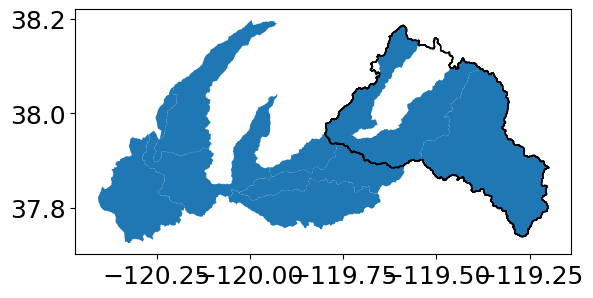

In [162]:
fig, ax = plt.subplots()
huc10_sierra[huc10_sierra['name'].str.contains('Tuolumne')].plot(ax=ax)
tuol.plot(ax=ax, facecolor='none')
#sierras.plot(ax=ax, facecolor='none', edgecolor='r')

<Axes: >

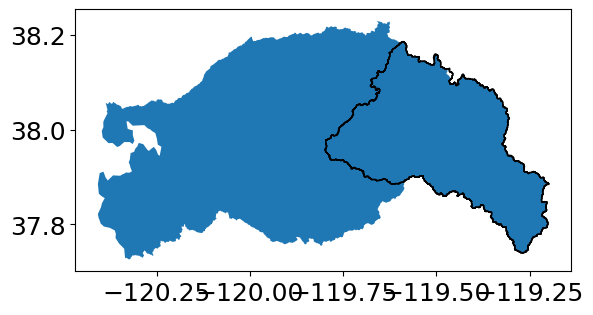

In [166]:
fig, ax = plt.subplots()
huc8_sierra[huc8_sierra['name'].str.contains('Tuolumne')].plot(ax=ax)
tuol.plot(ax=ax, facecolor='none')